# 04_02 · 模型每日拟合

本书将此前历史观测拟合成**一天固定使用的一组参数**。它产生参数表；逐点预测与评价分别在 04_03、04_04 完成。下方注释描述当前实现。

| 本书拟合的模型 | 训练时观察什么 | 参数用于预测什么 |
|---|---|---|
| GARCH、FIGARCH | 去季节性的采样区间 log 收益 | 未来采样区间的条件收益方差；在预测本中对照 RV |
| ARFIMA-logRV、ARFIMA-logBPV | 去季节性的采样区间 RV、BPV 的对数 | 未来采样区间对应代理的期望 |
| HAR，next_step | 历史事件 RV/BPV 的三个均值特征 | 下一个相邻采样区间的 RV/BPV |
| HAR，15m | 已完成事件构成的三个历史方差率特征 | 共同整数分钟末起算的未来十五分钟 RV/BPV，训练时先除以季节暴露 |

前三行中的“采样区间”随所选时钟而定，未必持续十五分钟。只有最后一行 HAR 在本书直接拟合十五分钟目标。04_04 对其余模型复用原生参数，再另做事件到十五分钟的转换；这里没有把所有模型改成直接拟合十五分钟标签。

**执行路线**：配置与输出契约 → 定义模型操作 → 验证模型操作 → 运行每日拟合／读取已有参数 → 诊断。标为“定义”的单元格只注册函数；真正读数据和拟合的位置在第 4 节。批次启动工具在附录，默认不开启。

**固定网格**：三种轴 × 5/10/15 等价分钟 × 不调整/BPV 30/60/120/360 交易日季节窗口 × 6/12 日历月训练窗口。每个配置每天有四个原生模型和四个 HAR 目标，共 720 条参数记录。每日窗口为 [D−months, D)，D 是拟合日零点；事件数自然变化。

**产出**：阶段目录中的 daily_fits_{fold_id}.parquet，每个 fold 一份参数表；保存参数、变换常数、训练范围、样本摘要和诊断。低成本观测量通过 04_01 调用 03 的历史时钟接口在内存重建；01 价格、02 季节因子及 03 既有采样文件由上游拥有。

价格仍沿用已接受的全快照复权和分钟内插值，研究属于离线探索。训练截止的检查不等于消除了上游价格的回溯性质。

**阅读与执行顺序**：[04_01 观测量构造](04_01_im_volatility_observations.ipynb) → [04_02 每日拟合](04_02_im_volatility_model_fitting.ipynb) → [04_03 下一采样步预测](04_03_im_next_step_volatility_forecasting.ipynb)／[04_04 未来15分钟预测](04_04_im_15m_volatility_forecasting.ipynb)。后两本相互独立，均消费第二本的日参数。


**阶段阅读导航**：[01_01 主力连续价格](01_01_im_main_continuous.ipynb) → [02_01 BPV季节因子](02_01_im_bpv_intraday_seasonality.ipynb)（[02_02 窗口比较](02_02_im_bpv_window_comparison.ipynb)）→ [03_01 采样时钟与价格](03_01_im_clock_resampling.ipynb)（[03_02 时钟诊断](03_02_im_clock_comparison_diagnostics.ipynb)）→ [04_01 波动观测量](04_01_im_volatility_observations.ipynb) → [04_02 每日拟合](04_02_im_volatility_model_fitting.ipynb) → [04_03 下一采样步预测](04_03_im_next_step_volatility_forecasting.ipynb)／[04_04 未来15分钟预测](04_04_im_15m_volatility_forecasting.ipynb)。括号中的比较与诊断本用于查看对应阶段结果，不是下一阶段的数据生成依赖；最后两本预测相互独立。


## 1. 执行：配置实验范围与参数表契约

下面两格分别设置运行参数、展示结果字段。


In [2]:
# 执行：导入依赖、定位项目根目录、设置网格；本格尚未读取行情或拟合。
import pathlib
import sys
import os
import json
import hashlib
import time
import warnings
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from IPython.display import display

# 使用项目统一的标记文件规则定位根目录；从 Notebook 子目录运行也使用同一配置。
project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()
for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        if str(candidate_root) not in sys.path:
            sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")
from config.settings import settings

# 所有研究结果归入一个阶段目录；这里仅构造路径，目录在提交结果时才创建。
research_dir = candidate_root / "01_project_collection/JQ_strategy/draft_experiments"
stage_dir = research_dir / "im_volatility_forecasting"
# globals().get 保留批次注入的参数；没有注入时使用右侧默认值。
# fold 是各自冻结采样时钟的一段评价日期，不等于每日的训练窗口。
RUN_FOLDS = globals().get("RUN_FOLDS", ["validation_2025h1", "validation_2025h2", "validation_2026h1", "final_2026"])
RUN_CLOCKS = globals().get("RUN_CLOCKS", ["time", "volume", "money"])
RUN_GRANULARITIES = globals().get("RUN_GRANULARITIES", [5, 10, 15])
# LOOKBACKS 的单位是交易日，控制上游季节曲线；0 表示因子恒为 1。
RUN_LOOKBACKS = globals().get("RUN_LOOKBACKS", [0, 30, 60, 120, 360])
# WINDOWS 的单位是日历月；由 DateOffset 截取，事件数不固定。
RUN_WINDOWS = globals().get("RUN_WINDOWS", [6, 12])
# 以下日期只筛选需要拟合的日期，不替代每个日期自己的历史窗口。
EVALUATION_START = globals().get("EVALUATION_START", None)
EVALUATION_END = globals().get("EVALUATION_END", None)
# 默认执行计算并提交每日参数；仅查看已有结果时设置 READ_RESULTS_ONLY=True。
# WRITE_OUTPUTS=False 仍可读取已有结果，但不会把本次新增参数写到文件。
WRITE_OUTPUTS = globals().get("WRITE_OUTPUTS", True)
READ_RESULTS_ONLY = globals().get("READ_RESULTS_ONLY", False)
MAX_RUN_SECONDS = globals().get("MAX_RUN_SECONDS", None)
# 方法版本与输入摘要共同阻止混用旧结果；注释及布局调整不改变方法版本。
METHOD_VERSION = "im_volatility_daily_v2"
NATIVE_MODELS = ["GARCH", "FIGARCH", "ARFIMA-logRV", "ARFIMA-logBPV"]
# 这些是运行入口的资格门槛；不足时写 insufficient_history 记录，不强行估计。
MIN_NATIVE_OBSERVATIONS = 500
MIN_HAR_OBSERVATIONS = 100
print("Python:", sys.executable)
print("阶段目录:", stage_dir)
print("参数网格:", len(RUN_CLOCKS)*len(RUN_GRANULARITIES)*len(RUN_LOOKBACKS)*len(RUN_WINDOWS)*8, "rows / trading day")

Python: E:\anaconda3\envs\latitude\python.exe
阶段目录: E:\Latitude_Analytics_v2\01_project_collection\JQ_strategy\draft_experiments\im_volatility_forecasting
参数网格: 720 rows / trading day


In [3]:
# 执行：声明参数表的 Arrow 契约并展示字段；本格不写文件。
# 一行 = 一个 fold/轴/粒度/季节窗口/训练窗口/模型/目标/期限/拟合日。
fit_schema = pa.schema([
    pa.field("fold_id", pa.string(), False),
    pa.field("clock", pa.string(), False),
    pa.field("equivalent_minutes", pa.int16(), False),
    pa.field("seasonality_lookback", pa.int16(), False),
    pa.field("fit_window_months", pa.int16(), False),
    # target 是评价代理：GARCH/FIGARCH 虽使用收益拟合，也标 rv 供下游评价。
    pa.field("model", pa.string(), False),
    pa.field("target", pa.string(), False),
    # native = 可供两个预测任务复用；next_step/15m = HAR 的两种直接目标。
    pa.field("horizon", pa.string(), False),
    pa.field("fit_date", pa.date32(), False),
    # window_start/end 是日历界限；first/last_observation_at 是实际训练观测的时间。
    pa.field("window_start", pa.timestamp("us", tz="Asia/Shanghai"), False),
    pa.field("window_end", pa.timestamp("us", tz="Asia/Shanghai"), False),
    pa.field("first_observation_at", pa.timestamp("us", tz="Asia/Shanghai")),
    pa.field("last_observation_at", pa.timestamp("us", tz="Asia/Shanghai")),
    # n_obs 计有效训练值（HAR 计标签行）；缺失与失败通过 status/message 保留。
    pa.field("n_obs", pa.int64(), False),
    pa.field("status", pa.string(), False),
    pa.field("message", pa.string(), False),
    # 只存参数及变换常数。状态数组和创新样本由后续 Notebook 用历史重新恢复。
    pa.field("payload_json", pa.string()),
    # fit_seconds 包含该行样本筛选、估计及必要恢复检查；不含整折观测/特征缓存构建。
    pa.field("fit_seconds", pa.float64(), False),
    pa.field("iterations", pa.int32()),
    pa.field("objective", pa.float64()),
    pa.field("boundary_hit", pa.bool_(), False),
    # training_digest 标识实际训练值与时间（HAR 另含特征）；input_sha256 标识输入 bundle。
    pa.field("training_digest", pa.string(), False),
    pa.field("input_sha256", pa.string(), False),
], metadata={
    b"table_name": b"im_volatility_daily_fits",
    b"method_version": METHOD_VERSION.encode(),
    b"primary_key": b"fold_id,clock,equivalent_minutes,seasonality_lookback,fit_window_months,model,target,horizon,fit_date",
    b"description": "每日滚动波动模型参数；本地研究产物，不写正式湖".encode(),
})
# 读取输出前先展示字段、类型、nullable；输入字段由观测量入口的局部 Arrow 契约拥有。
display(pd.DataFrame([{"field": f.name, "arrow_type": str(f.type), "nullable": f.nullable} for f in fit_schema]))

,field,arrow_type,nullable
0,fold_id,string,False
1,clock,string,False
2,equivalent_minutes,int16,False
3,seasonality_lookback,int16,False
4,fit_window_months,int16,False
5,model,string,False
6,target,string,False
7,horizon,string,False
8,fit_date,date32[day],False
9,window_start,"timestamp[us, tz=Asia/Shanghai]",False


## 2. 原生模型：估计参数 → 恢复状态 → 预测 → 更新状态

本节只定义操作。第 4 节调用估计函数，并恢复一次状态检查预测是否有限；04_03、04_04 则按相同顺序加载本节所有 model-kernels 单元格，用于每日恢复与日内递推。

收益模型采用零均值 Gaussian QML，以训练收益的**均方根 RMS**改善数值尺度。ARFIMA 对 log(proxy+c) 进行 Whittle 估计，并用训练创新样本还原水平期望。具体输入、输出、变换及状态内容见各函数的就地注释。

FIGARCH 的 ARCH(∞) 近似与 ARFIMA 的分数滤波均固定 1000 项，这是计算设置；六个月／十二个月训练窗口仍按日历截取，不是各取 1000 个样本。


### 2.1 定义：估计原生模型参数

第 4 节按模型选择输入并调用 fit_native_model。


In [4]:
# 定义：四个原生模型的估计、状态恢复、预测和更新操作。
# 后续预测本按 model-kernels 标签顺序加载；这些定义本身不启动拟合。
import warnings
import collections
import numpy as np
from scipy.optimize import minimize, nnls
from scipy.signal import lfilter
from scipy.special import logsumexp
from arch.univariate import ZeroMean, GARCH, FIGARCH, Normal
from arch.univariate.recursions import figarch_weights

# 固定滤波近似长度，不是日历训练窗口，也不参与本次对照网格。
MODEL_MEMORY = 1000

def fit_native_model(model, values):
    """用一条已去季节性的历史序列估计一个原生模型。

    model 决定 values 的业务含义，调用侧已经完成日期和资格筛选：
      GARCH/FIGARCH：区间 log 收益 / sqrt(起点季节因子)，可正可负；
      ARFIMA-logRV/logBPV：区间 RV 或 BPV / 起点季节因子，必须非负。
    values 按事件时间升序排列；ARFIMA 的取对数操作在本函数内部完成。

    返回可序列化的 payload：参数、数值/对数变换常数、收敛和边界诊断。
    这里不产生逐点预测，也不保存拟合对象；horizon=native 的参数供两本预测复用。
    """
    values = np.asarray(values, dtype=np.float64)
    if values.ndim != 1 or len(values) < 100 or not np.isfinite(values).all():
        raise ValueError("原生拟合需要至少 100 个有限一维观测")
    # 1. 收益模型：先改善数值尺度，再由 arch 估计零均值条件方差。
    if model in ("GARCH", "FIGARCH"):
        # RMS = sqrt(mean(r²))；这是数值缩放，不是年化，也不改变事件时间单位。
        numeric_scale = float(np.sqrt(np.mean(values**2)))
        if numeric_scale <= 0:
            raise ValueError("收益全部为零，不能估计条件方差")
        scaled_values = values / numeric_scale
        volatility = (
            GARCH(p=1, o=0, q=1)
            if model == "GARCH"
            else FIGARCH(p=1, q=1, truncation=MODEL_MEMORY)
        )
        arch_model = ZeroMean(scaled_values, volatility=volatility, distribution=Normal(), rescale=False)
        # 优化警告保留在 message；收敛失败作为研究结果记录，不自动换模型或重试。
        with warnings.catch_warnings(record=True) as fit_warnings:
            warnings.simplefilter("always")
            fitted_model = arch_model.fit(
                disp="off",
                show_warning=False,
                options={"maxiter": 300, "ftol": 1e-8},
            )
        optimization = fitted_model.optimization_result
        parameters = {str(k): float(v) for k, v in fitted_model.params.items()}
        finite = np.isfinite(list(parameters.values())).all()
        success = int(fitted_model.convergence_flag) == 0 and finite
        # 当前边界指标：GARCH 仅检查 alpha/beta 接近 0；FIGARCH 仅检查 d 接近 0/1。
        boundary_hit = (
            (parameters.get("alpha[1]", 1) < 1e-6 or parameters.get("beta[1]", 1) < 1e-6)
            if model == "GARCH"
            else any(abs(parameters.get("d", .5) - v) < 1e-5 for v in (0., 1.))
        )
        return {"model": model, "params": parameters, "numeric_scale": numeric_scale,
                "memory": MODEL_MEMORY, "status": "success" if success else "failed",
                "message": str(optimization.message) + ("; " + "; ".join(str(w.message) for w in fit_warnings) if fit_warnings else ""),
                "iterations": int(optimization.nit), "objective": float(optimization.fun),
                "boundary_hit": bool(boundary_hit)}
    # 2. 波动代理模型：对 log(proxy+c) 估计 ARFIMA(1,d,1)。
    if model not in ("ARFIMA-logRV", "ARFIMA-logBPV"):
        raise ValueError(f"未知原生模型: {model}")
    if np.any(values < 0) or not np.any(values > 0):
        raise ValueError("ARFIMA 波动代理须非负且至少一个正值")
    # 零代理通过很小的训练内偏移允许取 log；偏移和 log 均值在当日预测中固定。
    log_offset = float(1e-6 * np.mean(values[values > 0]))
    log_values = np.log(values + log_offset)
    log_mean = float(np.mean(log_values))
    centered_values = log_values - log_mean
    # 去掉零频；偶数样本另去掉 Nyquist 端点。谱估计使用整个日历窗口的有效序列。
    frequencies = 2*np.pi*np.fft.rfftfreq(len(values))[1:]
    periodogram = np.abs(np.fft.rfft(centered_values)[1:])**2 / len(values)
    if len(values) % 2 == 0:
        frequencies, periodogram = frequencies[:-1], periodogram[:-1]
    cosine = np.cos(frequencies)
    fractional_log = np.log(2*np.sin(frequencies/2))
    if np.mean(periodogram) <= 0:
        raise ValueError("对数代理为常数，Whittle 谱退化")
    # Whittle 目标消去创新方差尺度；谱形状由 AR、MA 和分数差分的三个参数控制。
    def whittle_objective(parameters):
        phi, theta, fractional_d = parameters
        numerator = 1+theta**2+2*theta*cosine
        denominator = 1+phi**2-2*phi*cosine
        log_spectrum = np.log(numerator)-np.log(denominator)-2*fractional_d*fractional_log
        weighted_periodogram = periodogram*np.exp(-log_spectrum)
        average_ratio = np.mean(weighted_periodogram)
        objective = float(np.mean(log_spectrum)+np.log(average_ratio))
        derivatives = np.column_stack(((2*cosine-2*phi)/denominator,
                                      (2*theta+2*cosine)/numerator,
                                      -2*fractional_log))
        gradient = np.mean(derivatives,axis=0)-(weighted_periodogram[:,None]*derivatives).sum(axis=0)/weighted_periodogram.sum()
        return objective, gradient
    # phi/theta 的边界限制 AR/MA 根；d 的搜索范围在本实验中固定，不另行选阶。
    optimization = minimize(
        whittle_objective,
        [.2, .05, .2],
        jac=True,
        method="L-BFGS-B",
        bounds=[(-.98, .98), (-.98, .98), (-.45, .49)],
        options={"maxiter": 300, "ftol": 1e-10, "gtol": 1e-7},
    )
    phi, theta, fractional_d = map(float, optimization.x)
    boundary_hit = any(min(abs(value-low), abs(value-high)) < 1e-5
                       for value,(low,high) in zip(optimization.x,[(-.98,.98),(-.98,.98),(-.45,.49)]))
    return {"model": model, "params": {"phi":phi,"theta":theta,"d":fractional_d},
            "numeric_scale":1.0,"log_offset":log_offset,"log_mean":log_mean,"training_n":len(values),
            "memory":MODEL_MEMORY,"status":"success" if optimization.success else "failed",
            "message":str(optimization.message),"iterations":int(optimization.nit),
            "objective":float(optimization.fun),"boundary_hit":bool(boundary_hit)}


### 2.2 定义：用日参数恢复历史状态


In [ ]:
def restore_native_state(model, payload, values):
    """用固定的日参数，从对应训练历史恢复预测所需状态。

    model 与 payload 必须来自同一条日参数；values 使用估计时相同的顺序和去季节单位。
    本函数不再估计参数。调用侧还会检查训练样本数与摘要，防止恢复到另一份历史。

    返回仅存内存的 state：
      GARCH：最后的平方收益和条件方差；
      FIGARCH：固定长度的平方收益历史、权重及常数项；
      ARFIMA：对数历史、创新滤波权重、训练创新样本及多步还原缓存。
    每日重估后重新恢复；日内通过 update_native 吸收新观测。
    """
    values = np.asarray(values,dtype=np.float64)
    if len(values) == 0 or not np.isfinite(values).all():
        raise ValueError("恢复状态需要有限历史")
    parameters = payload["params"]
    state = {"model":model,"payload":payload,"updates":0}
    if model == "GARCH":
        scaled_values = values/payload["numeric_scale"]
        volatility = GARCH(p=1,o=0,q=1)
        parameter_array = np.array([parameters["omega"],parameters["alpha[1]"],parameters["beta[1]"]])
        variances = np.empty(len(values))
        # 从 arch 的 backcast 初值重新过滤整段训练收益，保持与库内方差递推一致。
        volatility.compute_variance(parameter_array,scaled_values,variances,
                                    volatility.backcast(scaled_values),volatility.variance_bounds(scaled_values))
        state.update(last_squared=float(scaled_values[-1]**2),last_variance=float(variances[-1]))
    elif model == "FIGARCH":
        scaled_values = values/payload["numeric_scale"]
        weights = np.asarray(
            figarch_weights(
                np.array([parameters["phi"], parameters["d"], parameters["beta"]]),
                1, 1, payload["memory"],
            )
        )
        volatility = FIGARCH(p=1,q=1,truncation=payload["memory"])
        # FIGARCH 的未来方差由平方收益的加权和给出；历史不足的左端用 backcast 补齐。
        history = np.full(payload["memory"],float(volatility.backcast(scaled_values)))
        count = min(len(values),len(history))
        history[-count:] = scaled_values[-count:]**2
        state.update(weights=weights,squared_history=history,omega_tilde=parameters["omega"]/(1-parameters["beta"]))
    else:
        centered_values = np.log(values+payload["log_offset"])-payload["log_mean"]
        memory = payload["memory"]
        # 构造 (1-L)^d 的递推系数，再叠加 AR/MA 得到从对数代理到创新的滤波器。
        fractional_weights = np.empty(memory+1)
        fractional_weights[0] = 1.
        for lag in range(1,memory+1):
            fractional_weights[lag] = fractional_weights[lag-1]*(lag-1-parameters["d"])/lag
        # (1-phi L)(1-L)^d/(1+theta L) 为创新滤波器。
        innovation_weights = lfilter([1.,-parameters["phi"]],[1.,parameters["theta"]],fractional_weights)
        innovations = lfilter(innovation_weights,[1.],centered_values)
        # 只从原训练区间取创新分布；直接恢复扩展历史时也不把日内新值加入还原样本。
        burn = min(memory,max(25,payload.get("training_n",len(values))//5))
        innovation_sample = innovations[burn:payload.get("training_n",len(values))]
        # 中心化训练创新，用其经验分布估计 exp(预测误差) 的均值。
        innovation_sample = innovation_sample-np.mean(innovation_sample)
        history = np.zeros(memory)
        count = min(memory,len(values))
        history[-count:] = centered_values[-count:]
        state.update(innovation_weights=innovation_weights,log_history=history,
                     innovation_sample=innovation_sample,psi=[1.],log_smearing=[],
                     innovation_variance=float(np.var(innovation_sample)))
    return state


### 2.3 定义：从当前状态预测未来事件


In [ ]:
def forecast_native(state, horizon=1):
    """从当前状态预测未来 horizon 个完整采样区间。

    state 是恢复后、或吸收已完成观测后的状态；horizon 是事件步数，不是日历分钟数。
    返回长度为 horizon 的数组，每一项对应一个未来事件，不是这些事件的累计波动。
    GARCH/FIGARCH 返回条件收益方差；ARFIMA 返回 RV/BPV 代理的水平期望。
    内部数值缩放/对数变换已还原，起点季节因子尚未乘回，单位为去季节性的方差/代理。

    本函数不吸收真实新观测。ARFIMA 只补充与当日参数及训练创新有关的缓存。
    04_03 使用 horizon=1；04_04 另外估计事件路径，再调用本函数并做十五分钟转换。
    """
    horizon = int(horizon)
    if horizon < 1:
        raise ValueError("horizon 须为正整数")
    model, payload = state["model"],state["payload"]
    parameters = payload["params"]
    forecasts = np.empty(horizon)
    if model == "GARCH":
        # 一步用最后观测；更远步以条件方差替代未知平方收益的条件期望。
        forecasts[0] = (
            parameters["omega"]
            + parameters["alpha[1]"] * state["last_squared"]
            + parameters["beta[1]"] * state["last_variance"]
        )
        for step in range(1,horizon):
            forecasts[step] = parameters["omega"]+(parameters["alpha[1]"]+parameters["beta[1]"])*forecasts[step-1]
        forecasts *= payload["numeric_scale"]**2
    elif model == "FIGARCH":
        # 在历史副本中追加预测平方收益，避免多步预测提前推进真实观测状态。
        history = state["squared_history"].copy()
        for step in range(horizon):
            forecasts[step] = state["omega_tilde"]+np.dot(state["weights"],history[::-1])
            history[:-1],history[-1] = history[1:],forecasts[step]
        forecasts *= payload["numeric_scale"]**2
    else:
        # 同样只推进预测路径的对数历史副本；真实日内历史留待 update_native 更新。
        history = state["log_history"].copy()
        weights = state["innovation_weights"]
        # 预测误差系数与经验创新的 MGF 仅依赖当日参数，可缓存复用。
        while len(state["psi"]) < horizon:
            lag = len(state["psi"])
            maximum_lag = min(lag,len(weights)-1)
            state["psi"].append(float(-np.dot(weights[1:maximum_lag+1],np.asarray(state["psi"])[lag-maximum_lag:lag][::-1])))
        # exp(E[log代理]) 不等于 E[代理]。逐步累计经验 MGF 做水平还原，
        # 该多步还原依赖训练创新近似独立同分布的假设；logsumexp 用于数值稳定。
        while len(state["log_smearing"]) < horizon:
            step = len(state["log_smearing"])
            log_mgf = float(logsumexp(state["psi"][step]*state["innovation_sample"])-np.log(len(state["innovation_sample"])))
            state["log_smearing"].append(log_mgf+(state["log_smearing"][-1] if step else 0.))
        for step in range(horizon):
            log_forecast = float(-np.dot(weights[1:],history[::-1]))
            exponent = payload["log_mean"]+log_forecast+state["log_smearing"][step]
            # 溢出使该预测失败；极小的还原结果只设正数下限，以便后续 QLIKE 可定义。
            if exponent > 700:
                raise FloatingPointError("ARFIMA 水平还原溢出；保留失败，不裁剪异常预测")
            forecasts[step] = max(float(np.exp(exponent)-payload["log_offset"]),np.finfo(float).tiny)
            history[:-1],history[-1] = history[1:],log_forecast
    if not np.isfinite(forecasts).all() or np.any(forecasts <= 0):
        raise FloatingPointError("模型产生非正或非有限的水平预测")
    return forecasts


### 2.4 定义：吸收一个已完成事件


In [ ]:
def update_native(state, value):
    """吸收一个已经完成、已经可用的事件观测，原地更新 state。

    value 的单位与 fit_native_model 的 values 相同，调用侧负责先去季节性。
    GARCH/FIGARCH 接收区间收益；ARFIMA 接收区间 RV/BPV，不是它们的预测值。
    状态更新不重估参数、不扩充 ARFIMA 的训练创新还原分布，函数没有返回新对象。
    预测本负责事件顺序及可用时间；本函数只执行一次数值递推。
    """
    value = float(value)
    if not np.isfinite(value):
        raise ValueError("状态更新观测必须有限")
    model,payload = state["model"],state["payload"]
    if model == "GARCH":
        # 先以旧状态求出刚完成事件的条件方差，再用该事件真实收益平方替换最新观测。
        state["last_variance"] = forecast_native(state,1)[0]/payload["numeric_scale"]**2
        state["last_squared"] = (value/payload["numeric_scale"])**2
    elif model == "FIGARCH":
        state["squared_history"][:-1] = state["squared_history"][1:]
        state["squared_history"][-1] = (value/payload["numeric_scale"])**2
    else:
        if value < 0:
            raise ValueError("ARFIMA RV/BPV 观测不能为负")
        state["log_history"][:-1] = state["log_history"][1:]
        state["log_history"][-1] = np.log(value+payload["log_offset"])-payload["log_mean"]
    # updates 是内存中的吸收次数，用于理解状态推进；不写入日参数文件。
    state["updates"] += 1


## 3. HAR：构造特征 → 估计回归 → 使用参数预测

本节只定义函数。两个期限分别估计，RV 与 BPV 也分别估计，共四个 HAR 版本。

下一步使用最近 1、ceil(60/g)、ceil(240/g) 个有效事件的均值。十五分钟使用已完成事件累计覆盖至少 15、60、240 个交易分钟的方差率；不足一个事件的历史边界不拆开，实际覆盖时间可能更长。源分钟收盘后，分钟内插值事件才可进入特征。

四个回归均使用非负最小二乘。尺度由当日训练样本估计，随参数保存；变量单位与对齐规则写在下方函数和第 4 节调用处。


### 3.1 定义：下一步的历史事件均值

第 4 节将本函数的第 i 行特征与第 i+1 个事件标签配对。


In [5]:
# 定义：HAR 的两种特征以及共用的估计/预测操作；实际调用在第 4 节和预测本。
import numpy as np
from scipy.optimize import nnls


def har_next_features(values, equivalent_minutes):
    """按事件个数构造下一采样步 HAR 的三个历史均值。

    values 是时间有序、已去季节性的 RV/BPV；equivalent_minutes 是时钟校准粒度 g。
    第 i 行特征包含 values[i]，准备预测 values[i+1]；目标向后错一行在调用侧完成。
    三个窗口为 1、ceil(60/g)、ceil(240/g) 个有效事件；开头历史不足的行保留 NaN。
    它们是事件个数窗口：成交量/额时钟上的实际分钟跨度并不固定为 60/240 分钟。
    返回形状 (len(values), 3) 的矩阵，本函数不估计回归系数。
    """
    values = np.asarray(values,dtype=np.float64)
    if not np.isfinite(values).all():
        raise ValueError("HAR 特征需先排除不合格事件")
    features = np.full((len(values),3),np.nan)
    # 前缀和一次计算；每个窗口均值由右端累计量减去左端累计量得到。
    cumulative = np.r_[0.,np.cumsum(values)]
    for column,width in enumerate((1,int(np.ceil(60/equivalent_minutes)),int(np.ceil(240/equivalent_minutes)))):
        if len(values) >= width:
            features[width-1:,column] = (cumulative[width:]-cumulative[:-width])/width
    return features


### 3.2 定义：十五分钟任务的历史方差率特征


In [ ]:
def har_15m_features(
    event_end_coordinates,
    durations,
    adjusted_values,
    origin_coordinates,
    source_available_coordinates=None,
):
    """在给定预测起点，构造三个仅使用已完成事件的历史方差率。

    event_end_coordinates：事件在公共交易分钟网格上的结束坐标，按时间排序。
    durations：每个事件实际覆盖的交易分钟数；adjusted_values：同事件去季节性的 RV/BPV。
    origin_coordinates：要产生特征的起点坐标；本实现由公共整数分钟末目标表给出。
    source_available_coordinates：事件所用源分钟收盘坐标，可晚于插值事件的结束坐标。

    先找在各起点已可用的最后一个事件，再向左累计至少 15/60/240 分钟的有效事件。
    不拆最左端事件，分母使用实际覆盖时长；缺失/休市段不增加有效事件时长。
    输出为 (起点数, 3) 的方差率矩阵；历史不足返回 NaN，不填零。
    这只是回顾历史构造特征，不使用未来事件数，不构造未来十五分钟标签。
    """
    event_end_coordinates = np.asarray(event_end_coordinates,dtype=np.float64)
    durations = np.asarray(durations,dtype=np.float64)
    adjusted_values = np.asarray(adjusted_values,dtype=np.float64)
    origin_coordinates = np.asarray(origin_coordinates,dtype=np.float64)
    if not (len(event_end_coordinates)==len(durations)==len(adjusted_values)):
        raise ValueError("事件特征数组长度不一致")
    if np.any(durations <= 0) or not np.isfinite(adjusted_values).all():
        raise ValueError("HAR 事件特征需正时长和有限代理")
    # 显式可用坐标由调用侧从 source_minute_at 查回分钟表；仅未传入时才用向上取整。
    availability = (np.ceil(event_end_coordinates-1e-9) if source_available_coordinates is None
                    else np.asarray(source_available_coordinates,dtype=np.float64))
    if np.any(np.diff(availability)<0):
        raise ValueError("事件可用时间必须非递减")
    # side='right' 纳入恰在起点可用的事件；end_positions 是已可用事件的数量。
    end_positions = np.searchsorted(availability,origin_coordinates+1e-9,side="right")
    # 这是有效事件覆盖时长的累计，不是把休市/无效区间当成有效分钟补入。
    duration_prefix = np.r_[0.,np.cumsum(durations)]
    proxy_prefix = np.r_[0.,np.cumsum(adjusted_values)]
    features = np.full((len(origin_coordinates),3),np.nan)
    for column,width in enumerate((15.,60.,240.)):
        # 向左找到覆盖至少 width 分钟的完整事件集合，保留最左端整事件。
        left_positions = np.searchsorted(duration_prefix,duration_prefix[end_positions]-width+1e-9,side="right")-1
        valid = (left_positions >= 0)&(end_positions > 0)
        valid_left = left_positions[valid]
        valid_end = end_positions[valid]
        # 分子为同一组事件代理之和，分母为这些事件的真实累计时长，单位是方差/分钟。
        actual_duration = duration_prefix[valid_end]-duration_prefix[valid_left]
        features[valid,column] = (proxy_prefix[valid_end]-proxy_prefix[valid_left])/actual_duration
    return features


### 3.3 定义：拟合 HAR 回归并使用参数


In [ ]:
def fit_har_model(features, targets):
    """用三个历史特征拟合一个 HAR 目标，返回可保存的回归参数。

    features 为 (n, 3)，targets 为 (n,)；调用侧已经对齐并筛选训练行。
    下一步 targets 是去季节性的下一事件 RV/BPV；
    十五分钟 targets 是十五分钟 RV/BPV 除以已知季节暴露，即去季节性的方差率。

    训练特征均值和正目标均值用于数值缩放，连同截距及三个 NNLS 系数保存。
    四个系数都限制非负；boundary_hit 在此表示存在接近零的系数，不代表拟合失败。
    """
    features,targets = np.asarray(features,dtype=np.float64),np.asarray(targets,dtype=np.float64)
    if features.ndim != 2 or features.shape != (len(targets),3):
        raise ValueError("HAR 需要三个历史特征")
    if not np.isfinite(features).all() or not np.isfinite(targets).all() or np.any(targets<0):
        raise ValueError("HAR 输入必须有限，目标必须非负")
    if not np.any(targets>0):
        raise ValueError("HAR 目标全部为零")
    # 缩放只用本次训练样本；常零特征的尺度设 1，保留该列本身为零。
    feature_scales = np.mean(features,axis=0)
    feature_scales = np.where(feature_scales>0,feature_scales,1.)
    target_scale = float(np.mean(targets[targets>0]))
    # 第一列为截距，其余三列为经过缩放的历史特征；只拟合这一次，不在日内重估。
    design = np.column_stack((np.ones(len(targets)),features/feature_scales))
    coefficients,residual_norm = nnls(design,targets/target_scale,maxiter=1000)
    return {"model":"HAR","coefficients":coefficients.tolist(),"feature_scales":feature_scales.tolist(),
            "target_scale":target_scale,"status":"success","message":"NNLS",
            "iterations":None,"objective":float(residual_norm**2/len(targets)),
            "boundary_hit":bool(np.any(coefficients<1e-10))}


def predict_har_model(payload, features):
    """把已保存的 HAR 参数用于一个或多个特征向量。

    payload 来自 fit_har_model；features 可以是单个三元素向量或 (n, 3) 矩阵。
    返回值已还原训练内数值尺度，尚未还原季节性：
    下一步调用侧乘事件起点因子，十五分钟调用侧乘目标区间季节暴露。
    不更新参数或历史；正数下限用于避免 QLIKE 接收零预测。
    """
    features = np.asarray(features,dtype=np.float64)
    was_vector = features.ndim == 1
    features = np.atleast_2d(features)
    design = np.column_stack((np.ones(len(features)),features/np.asarray(payload["feature_scales"])))
    forecast = design@np.asarray(payload["coefficients"])*payload["target_scale"]
    forecast = np.maximum(forecast,payload["target_scale"]*1e-12)
    return float(forecast[0]) if was_vector else forecast


### 3.4 执行：验证原生状态递推与 HAR 特征

运行下一格会实际做有限的合成数据检查：条件方差与 arch 的固定参数解析预测比较；恢复后递推与直接恢复扩展历史比较；HAR 检查常数方差率。它不读取研究行情、不写参数文件，也不运行研究网格。


In [6]:
# 核验独立的库预测与状态恢复；不保存测试文件，不运行额外研究网格。
import copy
verification_rng = np.random.default_rng(20260906)
verification_returns = verification_rng.normal(0,0.001,1600)
verification_rows = []
for verification_model in ("GARCH","FIGARCH"):
    verification_params = ({"omega":.03,"alpha[1]":.08,"beta[1]":.89} if verification_model=="GARCH"
                           else {"omega":.05,"phi":.2,"d":.35,"beta":.3})
    verification_payload = {"model":verification_model,"params":verification_params,"numeric_scale":.001,"memory":MODEL_MEMORY}
    verification_state = restore_native_state(verification_model,verification_payload,verification_returns)
    verification_volatility = GARCH(1,0,1) if verification_model=="GARCH" else FIGARCH(1,1,truncation=MODEL_MEMORY)
    library_model = ZeroMean(verification_returns/.001,volatility=verification_volatility,distribution=Normal(),rescale=False)
    library_forecast = library_model.fix(np.array(list(verification_params.values()))).forecast(horizon=5,reindex=False).variance.iloc[-1].to_numpy()*1e-6
    np.testing.assert_allclose(forecast_native(verification_state,5),library_forecast,rtol=1e-10,atol=1e-16)
    replay_state = copy.deepcopy(verification_state)
    for verification_value in verification_returns[-5:]:
        update_native(replay_state,verification_value)
    restored_state = restore_native_state(verification_model,verification_payload,np.r_[verification_returns,verification_returns[-5:]])
    np.testing.assert_allclose(forecast_native(replay_state,3),forecast_native(restored_state,3),rtol=1e-10,atol=1e-16)
    verification_rows.append({"model":verification_model,"library_forecast":"passed","restore_and_replay":"passed"})
verification_proxy = np.exp(verification_rng.normal(-14,.5,1600))
for verification_model in ("ARFIMA-logRV","ARFIMA-logBPV"):
    verification_payload = {"model":verification_model,"params":{"phi":.2,"theta":-.1,"d":.3},"numeric_scale":1.,
                            "log_offset":1e-12,"log_mean":float(np.log(verification_proxy+1e-12).mean()),
                            "memory":MODEL_MEMORY,"training_n":len(verification_proxy)}
    replay_state = restore_native_state(verification_model,verification_payload,verification_proxy)
    for verification_value in verification_proxy[-5:]:
        update_native(replay_state,verification_value)
    restored_state = restore_native_state(verification_model,verification_payload,np.r_[verification_proxy,verification_proxy[-5:]])
    np.testing.assert_allclose(forecast_native(replay_state,3),forecast_native(restored_state,3),rtol=1e-10,atol=1e-16)
    verification_rows.append({"model":verification_model,"library_forecast":"not applicable","restore_and_replay":"passed"})
constant_features = har_15m_features(np.arange(1.,401.),np.ones(400),np.full(400,2.),np.array([240.,300.]))
np.testing.assert_allclose(constant_features,2.)
verification_rows.append({"model":"HAR","library_forecast":"constant variance rate passed","restore_and_replay":"not applicable"})
display(pd.DataFrame(verification_rows))


,model,library_forecast,restore_and_replay
0,GARCH,passed,passed
1,FIGARCH,passed,passed
2,ARFIMA-logRV,not applicable,passed
3,ARFIMA-logBPV,not applicable,passed
4,HAR,constant variance rate passed,not applicable


## 4. 执行：逐 fold、逐交易日估计并保存参数

这是本书真正调用模型拟合的入口。循环结构保持在同一格中，按 A–F 六段注释顺序阅读：

A 选择已有结果读取／计算路径 → B 重建观测与检查历史结果 → C 缓存各配置特征 → D 按日截取训练样本 → E 拟合并记录 → F 提交当天结果。

READ_RESULTS_ONLY=True 时只读取完整参数表，EVALUATION_START/END 及轴／窗口筛选不作用于这一读取分支。计算分支可按配置缩小范围；已有同输入、同版本的参数行按主键跳过，失败行也不自动重试。WRITE_OUTPUTS=False 只控制计算分支不提交参数文件，仍会读取并复用已有参数。

训练历史可以包含此前的 test 日期：split 只决定哪些日期需要评价；每次训练仍按 D−months 至 D 截取。HAR 的特征历史和完整训练标签都必须落在允许范围内。MAX_RUN_SECONDS 在完成整日后检查，不会截断单日网格。


In [7]:
# A. 选择执行路径。只读分支返回已有完整表；else 才重建观测、筛选样本和拟合。
if READ_RESULTS_ONLY:
    # 本分支不重新拟合，检查完整 Schema（含方法版本 metadata），最后供第 5 节展示。
    fit_read_frames = []
    for fold_id in RUN_FOLDS:
        fit_path = stage_dir / f"daily_fits_{fold_id}.parquet"
        fit_table = pq.read_table(fit_path)
        if not fit_table.schema.equals(fit_schema,check_metadata=True):
            raise RuntimeError(f"参数表契约/方法版本不一致: {fit_path}")
        fit_read_frames.append(fit_table.to_pandas())
    fit_results_df = pd.concat(fit_read_frames,ignore_index=True)
    print("只读汇总每日参数:",len(fit_results_df),"rows")
else:
    from config.data_contracts import validate_arrow_table, arrow_to_pandas, pandas_to_arrow

    # 下游读取投影的类型明确列出；完整事件/目标契约归观测量 Notebook。
    # B. 声明需要消费的字段。这里是读取投影；观测量完整契约仍由 04_01 拥有。
    event_read_schema = pa.schema([
        pa.field("fold_id",pa.string()),pa.field("clock",pa.string()),pa.field("equivalent_minutes",pa.int16()),
        pa.field("split",pa.string()),pa.field("sample_number",pa.int64()),
        pa.field("sample_at",pa.timestamp("us",tz="Asia/Shanghai")),
        pa.field("previous_sample_at",pa.timestamp("us",tz="Asia/Shanghai")),
        pa.field("source_minute_at",pa.timestamp("us",tz="Asia/Shanghai")),
        pa.field("trading_date",pa.date32()),pa.field("start_coordinate",pa.float64()),pa.field("end_coordinate",pa.float64()),
        pa.field("trading_duration_minutes",pa.float64()),pa.field("log_return",pa.float64()),
        pa.field("rv",pa.float64()),pa.field("bpv",pa.float64()),pa.field("eligible",pa.bool_()),
        *[pa.field(f"seasonality_{lookback}",pa.float64()) for lookback in (30,60,120,360)],
    ])
    target_read_schema = pa.schema([
        pa.field("origin_at",pa.timestamp("us",tz="Asia/Shanghai")),
        pa.field("target_end_at",pa.timestamp("us",tz="Asia/Shanghai")),
        pa.field("trading_date",pa.date32()),pa.field("origin_coordinate",pa.float64()),
        pa.field("rv",pa.float64()),pa.field("bpv",pa.float64()),pa.field("eligible",pa.bool_()),
        *[pa.field(f"seasonal_exposure_{lookback}",pa.float64()) for lookback in (30,60,120,360)],
    ])
    # 这九列唯一定位一个日参数；相同主键已有失败行时也跳过，不做隐含重试。
    fit_key_columns = ["fold_id","clock","equivalent_minutes","seasonality_lookback","fit_window_months","model","target","horizon","fit_date"]
    all_fit_frames = []
    run_started = time.perf_counter()
    run_stopped = False

    # 加载 observation-kernel 只注册函数；紧接着调用 build_volatility_observations
    # 才会读上游价格/BPV并通过03重建历史时钟。上游展示、发布和批次格不会运行。
    observations_notebook_path = research_dir / "04_01_im_volatility_observations.ipynb"
    observations_notebook = json.loads(observations_notebook_path.read_text(encoding="utf-8"))
    observation_kernel_cells = [cell for cell in observations_notebook["cells"]
                                if cell["cell_type"] == "code" and "observation-kernel" in cell.get("metadata",{}).get("tags",[])]
    if not observation_kernel_cells:
        raise RuntimeError("观测量 Notebook 缺少 observation-kernel 定义")
    for observation_cell in observation_kernel_cells:
        exec(compile("".join(observation_cell["source"]),str(observations_notebook_path),"exec"),globals())
    observation_inputs = build_volatility_observations(research_dir,RUN_FOLDS)

    for fold_id in RUN_FOLDS:
        # 事件表每行对应一个采样区间；目标表是各采样方案共用的整数分钟末十五分钟标签。
        event_df = observation_inputs["events_by_fold"][fold_id].copy()
        target_df = observation_inputs["targets_15m_df"].copy()
        event_table = pa.Table.from_pandas(event_df.loc[:,event_read_schema.names],schema=event_read_schema,preserve_index=False)
        target_table = pa.Table.from_pandas(target_df.loc[:,target_read_schema.names],schema=target_read_schema,preserve_index=False)
        event_df = event_table.to_pandas().sort_values(["clock","equivalent_minutes","sample_at","split","sample_number"],kind="stable").reset_index(drop=True)
        target_df = target_table.to_pandas().sort_values("origin_at").reset_index(drop=True)
        if not event_df["fold_id"].eq(fold_id).all():
            raise ValueError("事件 fold_id 与配置不一致")
        input_sha256 = observation_inputs["manifest"]["fold_input_manifest_ids"][fold_id]
        # 只在该 fold 的 test 日期重估；后续训练允许使用在 D 之前已经实现的 test 观测。
        evaluation_dates = sorted(event_df.loc[event_df["split"].eq("test"),"trading_date"].unique())
        if EVALUATION_START is not None:
            evaluation_dates = [d for d in evaluation_dates if d >= pd.Timestamp(EVALUATION_START).date()]
        if EVALUATION_END is not None:
            evaluation_dates = [d for d in evaluation_dates if d <= pd.Timestamp(EVALUATION_END).date()]
        output_path = stage_dir / f"daily_fits_{fold_id}.parquet"
        fit_rows = []
        # 复用旧参数前核对方法、字段和整折输入身份；不把新源数据与旧参数拼在一起。
        if output_path.exists():
            existing_table = pq.read_table(output_path)
            if existing_table.schema.metadata.get(b"method_version") != METHOD_VERSION.encode():
                raise RuntimeError("已有参数文件方法版本不同，不能静默复用")
            if not existing_table.schema.equals(fit_schema,check_metadata=False):
                raise RuntimeError("已有参数文件 Schema 不匹配")
            if existing_table.num_rows and set(existing_table.column("input_sha256").to_pylist()) != {input_sha256}:
                raise RuntimeError("输入快照已变化，不能拼接旧参数；请选择新实验目录或明确重建")
            fit_rows = existing_table.to_pylist()
        existing_keys = {tuple(row[name] for name in fit_key_columns) for row in fit_rows}

        # C. 每折预计算各轴/粒度/季节配置的有序观测和 HAR 特征，供全部拟合日共用。
        # 这一步只做确定性的历史滚动统计；回归系数和数值尺度仍每天重新估计。
        configuration_cache = {}
        for clock in RUN_CLOCKS:
            for equivalent_minutes in RUN_GRANULARITIES:
                group_df = event_df.loc[event_df["clock"].eq(clock)&event_df["equivalent_minutes"].eq(equivalent_minutes)].reset_index(drop=True)
                if group_df.empty:
                    raise ValueError(f"缺少事件配置 {fold_id}/{clock}/{equivalent_minutes}")
                for lookback in RUN_LOOKBACKS:
                    seasonality = np.ones(len(group_df)) if lookback == 0 else group_df[f"seasonality_{lookback}"].to_numpy(dtype=float)
                    # 季节曲线可能尚未预热或为零；只让基础合格且因子有限为正的事件进入模型。
                    valid_seasonality = np.isfinite(seasonality)&(seasonality>0)
                    eligible = group_df["eligible"].fillna(False).to_numpy(dtype=bool)&valid_seasonality
                    configuration = {"group_df":group_df,"seasonality":seasonality,"eligible":eligible,"series":{}}
                    for target in ("rv","bpv"):
                        proxy = group_df[target].to_numpy(dtype=float)
                        valid = eligible&np.isfinite(proxy)&(proxy>=0)
                        # 记录筛选前的位置，稍后判断 HAR 下一步标签是否真的是物理相邻事件。
                        original_positions = np.flatnonzero(valid)
                        proxy_df = group_df.loc[valid].copy().reset_index(drop=True)
                        # RV/BPV 位于方差尺度，直接除以起点因子；收益在 D 段除以因子平方根。
                        adjusted_values = proxy[valid]/seasonality[valid]
                        # 分钟内插值事件要等源分钟收盘才可用于十五分钟 HAR 特征。
                        # 全局源分钟 i 的结束坐标是 i+1；不能只用虚拟事件时间判断可用。
                        available_positions = pd.DatetimeIndex(observation_inputs["minute_measures_df"]["bar_at"]).get_indexer(pd.DatetimeIndex(proxy_df["source_minute_at"]))
                        if np.any(available_positions < 0):
                            raise ValueError("HAR事件来源分钟不在公共分钟表中")
                        available_coordinates = available_positions.astype(float)+1.
                        # next_features[i] 使用截至事件 i 的历史，next_targets[i] 是事件 i+1 的代理。
                        next_features = har_next_features(adjusted_values,equivalent_minutes)
                        next_targets = np.r_[adjusted_values[1:],np.nan]
                        next_target_at = proxy_df["sample_at"].shift(-1)
                        # 若中间删过不合格事件，两个有效行相邻也不代表它们在原采样序列相邻。
                        adjacent_pair = np.r_[np.diff(original_positions)==1,False]
                        # 只纳入在拟合窗口内构造完成的 HAR 特征，避免左侧边界外的数据隐含进入。
                        longest_next = int(np.ceil(240/equivalent_minutes))
                        next_feature_start = proxy_df["previous_sample_at"].shift(longest_next-1)
                        origin_coordinates = target_df["origin_coordinate"].to_numpy(dtype=float)
                        # 十五分钟标签直接沿用公共目标表；下面只重算该采样配置可提供的历史特征。
                        features_15m = har_15m_features(
                            proxy_df["end_coordinate"].to_numpy(),
                            proxy_df["trading_duration_minutes"].to_numpy(),
                            adjusted_values,
                            origin_coordinates,
                            source_available_coordinates=available_coordinates,
                        )
                        # 无季节调整时暴露为 15；调整时为未来15分钟已知历史季节曲线之和。
                        # 标签 / 暴露 与历史 HAR 特征同为去季节性方差率。
                        exposure = np.full(len(target_df),15.) if lookback == 0 else target_df[f"seasonal_exposure_{lookback}"].to_numpy(dtype=float)
                        valid_exposure = np.isfinite(exposure)&(exposure>0)
                        with np.errstate(divide="ignore",invalid="ignore"):
                            targets_15m = target_df[target].to_numpy(dtype=float)/exposure
                        # 为每个目标起点额外记录最长特征（240有效分钟）的实际历史起点。
                        # 每日训练要检查它没有越过左侧日历窗口，不只检查标签日期。
                        end_positions = np.searchsorted(available_coordinates,origin_coordinates+1e-9,side="right")
                        duration_prefix = np.r_[0.,np.cumsum(proxy_df["trading_duration_minutes"].to_numpy(dtype=float))]
                        left_positions = np.searchsorted(duration_prefix,duration_prefix[end_positions]-240.+1e-9,side="right")-1
                        feature_start_15m = pd.Series(pd.NaT,index=target_df.index,dtype="datetime64[us, Asia/Shanghai]")
                        enough_history = left_positions >= 0
                        feature_start_15m.loc[enough_history] = proxy_df["previous_sample_at"].iloc[left_positions[enough_history]].to_numpy()
                        configuration["series"][target] = {
                            "df": proxy_df,
                            "values": adjusted_values,
                            "next_features": next_features,
                            "next_targets": next_targets,
                            "next_target_at": next_target_at,
                            "next_feature_start": next_feature_start,
                            "adjacent_pair": adjacent_pair,
                            "features_15m": features_15m,
                            "targets_15m": targets_15m,
                            "valid_exposure": valid_exposure,
                            "feature_start_15m": feature_start_15m,
                        }
                    configuration_cache[(clock,equivalent_minutes,lookback)] = configuration

        # D. 逐日截取训练数据。这里的 D 是上海时区当日零点，日内价格不会参与日初估计。
        for fit_date in evaluation_dates:
            window_end = pd.Timestamp(fit_date,tz="Asia/Shanghai")
            day_started = time.perf_counter()
            day_new_rows = 0
            for (clock,equivalent_minutes,lookback),configuration in configuration_cache.items():
                group_df = configuration["group_df"]
                for window_months in RUN_WINDOWS:
                    # DateOffset 按日历减月，例如 9月6日减6个月是3月6日；不换算成固定天数。
                    window_start = window_end-pd.DateOffset(months=int(window_months))
                    common_row = {
                        "fold_id": fold_id,
                        "clock": clock,
                        "equivalent_minutes": int(equivalent_minutes),
                        "seasonality_lookback": int(lookback),
                        "fit_window_months": int(window_months),
                        "fit_date": fit_date,
                        "window_start": window_start,
                        "window_end": window_end,
                        "input_sha256": input_sha256,
                    }
                    # 一个轴/粒度/季节窗口/历史窗口：4个原生 + HAR两目标×两期限 = 8行。
                    for model in [*NATIVE_MODELS,"HAR-next-rv","HAR-next-bpv","HAR-15m-rv","HAR-15m-bpv"]:
                        if model.startswith("HAR-"):
                            _,har_horizon,target = model.split("-")
                            horizon = "next_step" if har_horizon == "next" else "15m"
                            model_name = "HAR"
                        else:
                            # 原生 GARCH/FIGARCH 的 target=rv 指下游评价对象；拟合输入仍是收益。
                            target = "bpv" if model == "ARFIMA-logBPV" else "rv"
                            horizon,model_name = "native",model
                        row = dict(common_row,model=model_name,target=target,horizon=horizon)
                        key = tuple(row[name] for name in fit_key_columns)
                        if key in existing_keys:
                            continue
                        fit_started = time.perf_counter()
                        payload = None
                        # 样本摘要写进参数表。两本预测用同一数据重建原生状态时会复核此摘要。
                        training_hasher = hashlib.sha256()
                        n_obs = 0
                        first_at = last_at = None
                        try:
                            # 以下四条分支仅选择各自的训练值/标签，均先筛选再拟合。
                            if model in ("GARCH","FIGARCH"):
                                # 收益模型：整个事件要落在 [window_start, window_end) 内。
                                observed_returns = group_df["log_return"].to_numpy(dtype=float)
                                mask = (
                                    configuration["eligible"]
                                    & np.isfinite(observed_returns)
                                    & (group_df["previous_sample_at"] >= window_start).to_numpy()
                                    & (group_df["sample_at"] < window_end).to_numpy()
                                )
                                training_values = observed_returns[mask]/np.sqrt(configuration["seasonality"][mask])
                                observed_at = group_df.loc[mask,"sample_at"]
                            # ARFIMA：同一日历窗口内的事件 RV/BPV，函数内部才做 log 变换。
                            elif horizon == "native":
                                series = configuration["series"][target]
                                mask = (
                                    (series["df"]["previous_sample_at"] >= window_start)
                                    & (series["df"]["sample_at"] < window_end)
                                ).to_numpy()
                                training_values = series["values"][mask]
                                observed_at = series["df"].loc[mask,"sample_at"]
                            # 下一步 HAR：原序列物理相邻，最长特征不越左界，下一事件标签在 D 前实现。
                            elif horizon == "next_step":
                                series = configuration["series"][target]
                                mask = (
                                    series["adjacent_pair"]
                                    & np.isfinite(series["next_features"]).all(axis=1)
                                    & np.isfinite(series["next_targets"])
                                    & (series["next_feature_start"] >= window_start).to_numpy()
                                    & (series["next_target_at"] < window_end).to_numpy()
                                )
                                training_features,training_values = series["next_features"][mask],series["next_targets"][mask]
                                observed_at = series["next_target_at"].loc[mask]
                                training_hasher.update(np.ascontiguousarray(training_features).tobytes())
                            else:
                                # 十五分钟 HAR：完整标签结束时间 < D，且最长特征历史起点 >= 左界。
                                series = configuration["series"][target]
                                mask = (
                                    target_df["eligible"].to_numpy(dtype=bool)
                                    & series["valid_exposure"]
                                    & np.isfinite(series["features_15m"]).all(axis=1)
                                    & np.isfinite(series["targets_15m"])
                                    & (series["targets_15m"] >= 0)
                                    & (series["feature_start_15m"] >= window_start).to_numpy()
                                    & (target_df["target_end_at"] < window_end).to_numpy()
                                )
                                training_features,training_values = series["features_15m"][mask],series["targets_15m"][mask]
                                observed_at = target_df.loc[mask,"target_end_at"]
                                training_hasher.update(np.ascontiguousarray(training_features).tobytes())
                            # E. 记录实际样本，再估计一条日参数。n_obs 可随轴、日历月和资格自然变化。
                            n_obs = len(training_values)
                            training_hasher.update(np.ascontiguousarray(training_values).tobytes())
                            training_hasher.update(pd.DatetimeIndex(observed_at).asi8.tobytes())
                            if n_obs:
                                first_at,last_at = observed_at.iloc[0],observed_at.iloc[-1]
                            minimum = MIN_NATIVE_OBSERVATIONS if horizon == "native" else MIN_HAR_OBSERVATIONS
                            if n_obs < minimum:
                                status,message = "insufficient_history",f"有效样本 {n_obs} < {minimum}"
                            else:
                                payload = (
                                    fit_native_model(model, training_values)
                                    if horizon == "native"
                                    else fit_har_model(training_features, training_values)
                                )
                                status,message = payload["status"],payload["message"]
                                if status == "success" and horizon == "native":
                                    # 日参数只有能恢复状态且生成有限一步预测才算可复用；临时状态随即释放。
                                    native_state = restore_native_state(model,payload,training_values)
                                    forecast_native(native_state,1)
                                    del native_state
                        except (ValueError,FloatingPointError,RuntimeError,np.linalg.LinAlgError) as exception:
                            status,message = "failed",f"{type(exception).__name__}: {exception}"
                        # 只序列化小参数载荷；NaN/Inf 参数不能伪装成可复用 JSON。
                        try:
                            payload_json = json.dumps(payload,ensure_ascii=False,allow_nan=False) if payload is not None else None
                        except ValueError:
                            status,message,payload_json = "failed",message+"; 参数包含非有限值，未保存不可复用载荷",None
                            payload = None
                        row.update(
                            first_observation_at=first_at,
                            last_observation_at=last_at,
                            n_obs=int(n_obs),
                            status=status,
                            message=message,
                            payload_json=payload_json,
                            fit_seconds=float(time.perf_counter() - fit_started),
                            iterations=payload.get("iterations") if payload else None,
                            objective=payload.get("objective") if payload else None,
                            boundary_hit=bool(payload.get("boundary_hit", False)) if payload else False,
                            training_digest=training_hasher.hexdigest(),
                        )
                        fit_rows.append(row)
                        existing_keys.add(key)
                        day_new_rows += 1
            # F. 全部配置完成一天后，提交该 fold 累积参数表；并非为每个模型/时点创建文件。
            if WRITE_OUTPUTS and day_new_rows:
                stage_dir.mkdir(parents=True,exist_ok=True)
                fit_table = pa.Table.from_pylist(fit_rows,schema=fit_schema)
                if fit_table.to_pandas().duplicated(fit_key_columns).any():
                    raise RuntimeError("拟合参数主键重复")
                temporary_path = output_path.with_suffix(".parquet.tmp")
                try:
                    # 同目录暂存 → flush/fsync → 复读 Schema → 原子替换；finally 清理临时路径。
                    with temporary_path.open("wb") as output_file:
                        pq.write_table(fit_table,output_file,compression="zstd")
                        output_file.flush()
                        os.fsync(output_file.fileno())
                    written_schema = pq.read_schema(temporary_path)
                    if not written_schema.equals(fit_schema,check_metadata=True):
                        raise RuntimeError("参数 checkpoint 复读 Schema 不一致")
                    os.replace(temporary_path,output_path)
                finally:
                    if temporary_path.exists():
                        temporary_path.unlink()
            print(f"{fold_id} {fit_date} 完成 {day_new_rows} 行；耗时 {time.perf_counter()-day_started:.2f}s；累计 {len(fit_rows)} 行",flush=True)
            # 可选批次回调仅发布已完成一天的进度；研究估计不依赖监控进程中的模型状态。
            if callable(globals().get("RUN_PROGRESS")):
                RUN_PROGRESS("model_fitting",fold_id,str(fit_date),len(fit_rows))
            # 有界运行在完整日结束后停，不截断当前日期的 720 行默认网格。
            if MAX_RUN_SECONDS is not None and time.perf_counter()-run_started >= MAX_RUN_SECONDS:
                run_stopped = True
                break
        all_fit_frames.append(pa.Table.from_pylist(fit_rows,schema=fit_schema).to_pandas())
        del configuration_cache
        if run_stopped:
            break
    fit_results_df = pd.concat(all_fit_frames,ignore_index=True) if all_fit_frames else pa.Table.from_pylist([],schema=fit_schema).to_pandas()
    print("日拟合结果行数:",len(fit_results_df),"累计耗时:",round(time.perf_counter()-run_started,2),"秒")


只读汇总每日参数: 276480 rows


## 5. 执行：检查样本数、收敛、边界与耗时

本节消费第 4 节得到的 fit_results_df。它描述估计可用性与计算成本；输出中的 objective 随模型而异，不能拿来跨模型排名。边界参数只按各模型实现中指定的边界记录，不能等同于完整的参数稳定性检验。

下方半年／一年表比较样本量和耗时。预测损失及两窗共同评价样本由 04_03、04_04 管理。本格运行会展示表格和图，不写独立诊断文件。


fit_count  success_rate  boundary_rate  n_min  n_median  n_max  seconds_median  seconds_p95
fold_id           model         target horizon   fit_window_months                                                                                             
final_2026        ARFIMA-logBPV bpv    native    6                       2880      1.000000       0.329167   1417    3727.5  11068        0.004265     0.007962
                                                 12                      2880      1.000000       0.193056   2893    7619.5  20069        0.006781     0.012200
                  ARFIMA-logRV  rv     native    6                       2880      1.000000       0.355903   1417    3727.5  11068        0.004288     0.008510
                                                 12                      2880      1.000000       0.211806   2893    7619.5  20069        0.006379     0.013781
                  FIGARCH       rv     native    6                       2880      1.000000       0.006944   1417    3727.5  11068        0.261052     0.622642
                                                 12                      2880      1.000000       0.000000   2893    7619.5  20069        0.511768     1.129425
                  GARCH         rv     native    6                       2880      1.000000       0.000000   1417    3727.5  11068        0.013527     0.025406
                                                 12                      2880      1.000000       0.000000   2893    7619.5  20069        0.021468     0.042004
                  HAR           bpv    15m       6                       2880      1.000000       0.014583  23846   24312.0  25576        0.004866     0.005567
                                                 12                      2880      1.000000       0.011458  49838   50103.0  50327        0.007679     0.008975
                                       next_step 6                       2880      1.000000       0.072569   1168    3469.0  10773        0.000863     0.001601
                                                 12                      2880      1.000000       0.045139   2398    7113.5  19538        0.001079     0.002120
                                rv     15m       6                       2880      1.000000       0.014931  23846   24312.0  25576        0.004897     0.005629
                                                 12                      2880      1.000000       0.014236  49838   50103.0  50327        0.007622     0.008720
                                       next_step 6                       2880      1.000000       0.075347   1168    3469.0  10773        0.001042     0.001876
                                                 12                      2880      1.000000       0.008333   2398    7113.5  19538        0.001189     0.002319
validation_2025h1 ARFIMA-logBPV bpv    native    6                       4455      1.000000       0.128395   1399    5269.0  13421        0.004885     0.008216
                                                 12                      4455      1.000000       0.081033   2827    9108.0  21142        0.007066     0.012182
                  ARFIMA-logRV  rv     native    6                       4455      1.000000       0.141639   1399    5269.0  13421        0.005000     0.010147
                                                 12                      4455      1.000000       0.076094   2827    9108.0  21142        0.006894     0.015476
                  FIGARCH       rv     native    6                       4455      0.999327       0.002020   1399    5269.0  13421        0.338789     0.774501
                                                 12                      4455      0.999327       0.001122   2827    9108.0  21142        0.575626     1.304513
                  GARCH         rv     native    6                       4455      1.000000       0.000000   1399    5269.0  13421        0.016201     0.031998
                                                 12                 

n_obs          fit_seconds             n_ratio time_ratio
fit_window_months                    6        12          6         12        12         12
model         target horizon                                                               
ARFIMA-logBPV bpv    native      4353.0   8744.5    0.004563  0.007113  1.970451   1.515194
ARFIMA-logRV  rv     native      4353.0   8744.5    0.004649  0.006794  1.970451   1.468988
FIGARCH       rv     native      4353.0   8744.5    0.287237  0.563540  1.970451   1.946664
GARCH         rv     native      4353.0   8744.5    0.015212  0.023149  1.970451   1.519569
HAR           bpv    15m        24327.0  50102.0    0.004893  0.007532  2.043393   1.531022
                     next_step   4083.0   8239.5    0.000885  0.001131  1.973312   1.252825
              rv     15m        24327.0  50102.0    0.004952  0.007574  2.043393   1.523169
                     next_step   4083.0   8239.5    0.001060  0.001232  1.973312   1.146132

,fold_id,clock,equivalent_minutes,seasonality_lookback,model,target,horizon,fit_date,fit_window_months,n_obs,status,message
55209,validation_2025h1,money,5,0,FIGARCH,rv,native,2025-02-21,12,17954,failed,Positive directional derivative for linesearch
60969,validation_2025h1,money,5,0,FIGARCH,rv,native,2025-03-05,12,18196,failed,Positive directional derivative for linesearch
72969,validation_2025h1,volume,5,0,FIGARCH,rv,native,2025-03-28,12,19241,failed,Positive directional derivative for linesearch
74257,validation_2025h1,time,10,30,FIGARCH,rv,native,2025-04-01,6,2439,failed,Positive directional derivative for linesearch
79441,validation_2025h1,volume,5,0,FIGARCH,rv,native,2025-04-11,6,12623,failed,Positive directional derivative for linesearch
114481,validation_2025h1,time,5,0,FIGARCH,rv,native,2025-06-25,6,5383,failed,Inequality constraints incompatible
171129,validation_2025h2,money,5,0,FIGARCH,rv,native,2025-10-21,12,21570,failed,Positive directional derivative for linesearch
240561,validation_2026h1,time,10,0,FIGARCH,rv,native,2026-03-17,6,2391,failed,Positive directional derivative for linesearch


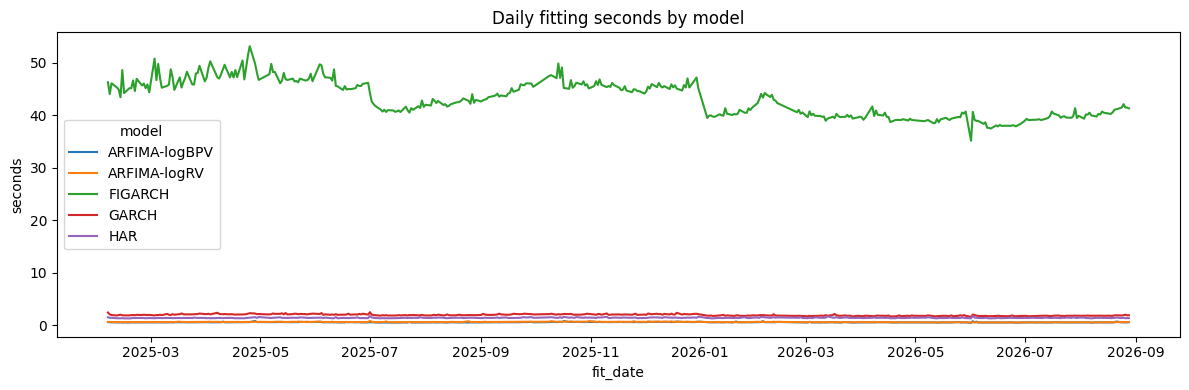

In [8]:
# 执行：汇总已有 fit_results_df。不会在本格重新估计，也不会单独保存统计文件。
if not fit_results_df.empty:
    display(fit_results_df.groupby(["fold_id","model","target","horizon","fit_window_months"],dropna=False).agg(
        fit_count=("status","size"),success_rate=("status",lambda values:values.eq("success").mean()),
        boundary_rate=("boundary_hit","mean"),n_min=("n_obs","min"),n_median=("n_obs","median"),n_max=("n_obs","max"),
        seconds_median=("fit_seconds","median"),seconds_p95=("fit_seconds",lambda values:values.quantile(.95))))
    # 配对时只移除历史窗口长度；其他配置及拟合日一致，才能解释样本量/耗时比值。
    paired_keys = ["fold_id","clock","equivalent_minutes","seasonality_lookback","model","target","horizon","fit_date"]
    window_comparison_df = fit_results_df.pivot(index=paired_keys,columns="fit_window_months",values=["n_obs","fit_seconds"])
    if 6 in window_comparison_df["n_obs"] and 12 in window_comparison_df["n_obs"]:
        window_comparison_df[("n_ratio",12)] = window_comparison_df[("n_obs",12)]/window_comparison_df[("n_obs",6)]
        window_comparison_df[("time_ratio",12)] = window_comparison_df[("fit_seconds",12)]/window_comparison_df[("fit_seconds",6)]
    display(window_comparison_df.groupby(level=["model","target","horizon"]).median(numeric_only=True))
    # 失败原因来自拟合/资格检查，保留原始消息；此处仅展示前50行。
    failures_df = fit_results_df.loc[~fit_results_df["status"].eq("success")]
    display(failures_df[[*paired_keys,"fit_window_months","n_obs","status","message"]].head(50))
    import matplotlib.pyplot as plt
    # 图中的日耗时为各记录 fit_seconds 之和，不含公共输入重建和结果文件提交。
    timing_df = fit_results_df.groupby(["fit_date","model"],observed=True)["fit_seconds"].sum().unstack()
    axes = timing_df.plot(figsize=(12,4),title="Daily fitting seconds by model",ylabel="seconds")
    plt.tight_layout()
    plt.show()
else:
    print("没有拟合结果，请检查 RUN_FOLDS 和评价日期范围。")

## 6. 文献依据与本研究选择

收益条件方差模型依据 [Bollerslev（1986）](https://econ.duke.edu/~boller/Published_Papers/joe_86.pdf) 与 [Baillie 等（1996）](https://public.econ.duke.edu/~boller/Published_Papers/joe_96a.pdf)；多尺度波动回归参考 [Corsi（2009）](https://doi.org/10.1093/jjfinec/nbp001)；对数已实现波动建模参考 [Andersen 等（2003）](https://econ.duke.edu/~boller/Published_Papers/ecta_03.pdf)，水平还原参考 [Duan（1983）](https://www.tandfonline.com/doi/abs/10.1080/01621459.1983.10478017)。

日内 HAR 的具体尺度和 NNLS、ARFIMA 的 Whittle 估计与经验 MGF 多步还原是本研究的工程选择，依赖训练创新近似独立同分布的假设，并非对上述论文逐项复现。1000 项是两个历史窗口共同固定的计算设置，不是新增记忆截断分支实验。


## 附录 A · 可选的完整阶段批次

默认只定义启动器，`LAUNCH_STAGE_BATCH=False`，不会自动启动。一个批次固定包含四个已确认日期区段；最多四个 fold 并行，每个 fold 严格依次完成全部每日拟合 → 下一步预测 → 15 分钟预测。参数与预测落盘，低成本观测在内存重建。worker 不写源 Notebook；全部成功后协调器串行只读汇总并保存四本 Notebook 的诊断输出。

使用标准 latitude_env_v2 Python、每个 kernel 的 BLAS 线程为 1。协调器与 worker 隐藏运行，独立 PowerShell monitor 可见且不依赖 Codex。普通失败、状态发布失败或 monitor 退出都会终止后续阶段，不自动重试。必要状态及日志位于阶段目录的单个批次子目录；临时 kernel 资源成功关闭后清理，失败现场保留。

启动后只做一次有界健康检查，确认协调器、worker、kernel、状态心跳及可见 monitor 正常后即可结束 Agent 回合。不要以持续轮询维持 Agent 存活。


In [9]:
# 定义：附录的批次运行工具。本格不创建进程，不拟合，也不写状态文件。
# 调用关系：协调器 → 每折 worker → 独立 Notebook kernel → 研究执行格。

def publish_batch_status(status_path, status):
    """控制面唯一写入规则：同目录临时文件、flush/fsync、原子替换。"""
    import json
    import os
    import pathlib
    import time
    import threading
    status_write_lock = globals().setdefault("BATCH_STATUS_WRITE_LOCK",threading.RLock())
    with status_write_lock:
        status_path = pathlib.Path(status_path)
        temporary_path = status_path.with_name(status_path.name+f".{os.getpid()}.tmp")
        with temporary_path.open("w",encoding="utf-8",newline="\n") as status_file:
            json.dump(status,status_file,ensure_ascii=False,allow_nan=False)
            status_file.flush()
            os.fsync(status_file.fileno())
        for attempt in range(6):
            try:
                os.replace(temporary_path,status_path)
                break
            except OSError as exception:
                if getattr(exception,"winerror",None) not in (5,32) or attempt==5:
                    raise
                time.sleep(.05*(2**attempt))


# 检查既有进程是否仍在运行，供协调器判断 monitor/worker 是否可用。
def batch_process_is_running(process_id):
    """Windows 只读查询进程，不使用 os.kill(pid, 0)。"""
    import ctypes
    kernel32 = ctypes.WinDLL("kernel32",use_last_error=True)
    kernel32.OpenProcess.argtypes = [ctypes.c_ulong,ctypes.c_int,ctypes.c_ulong]
    kernel32.OpenProcess.restype = ctypes.c_void_p
    kernel32.GetExitCodeProcess.argtypes = [ctypes.c_void_p,ctypes.POINTER(ctypes.c_ulong)]
    kernel32.CloseHandle.argtypes = [ctypes.c_void_p]
    handle = kernel32.OpenProcess(0x1000,False,int(process_id))
    if not handle:
        return False
    try:
        exit_code = ctypes.c_ulong()
        return bool(kernel32.GetExitCodeProcess(handle,ctypes.byref(exit_code))) and exit_code.value==259
    finally:
        kernel32.CloseHandle(handle)


# 执行一个 Notebook：注入该折参数、创建独立内核、运行、清理；可选保存原 Notebook 输出。
def execute_batch_notebook(notebook_path, config, *, fold_id=None, read_results_only=False, save_canonical=False):
    """一个隔离的 latitude_env_v2 kernel；worker 不写源 Notebook，协调器最后单独发布输出。"""
    import hashlib
    import json
    import os
    import pathlib
    import tempfile
    import uuid
    import nbformat
    from nbclient import NotebookClient
    from jupyter_client import KernelManager
    notebook_path = pathlib.Path(notebook_path)
    notebook = nbformat.read(notebook_path,as_version=4)
    notebook.cells = [cell for cell in notebook.cells if "injected-parameters" not in cell.get("metadata",{}).get("tags",[])]
    runtime_notebook = json.loads(pathlib.Path(config["runtime_notebook"]).read_text(encoding="utf-8"))
    # 仅提取带 batch-runtime 标签的定义。源码摘要保证同一活动批次不混用两个实现版本。
    runtime_source = "\n".join("".join(cell["source"]) for cell in runtime_notebook["cells"]
                              if "batch-runtime" in cell.get("metadata",{}).get("tags",[]))
    if hashlib.sha256(runtime_source.encode()).hexdigest()!=config["runtime_sha256"]:
        raise RuntimeError("批次运行期间 batch-runtime 源代码变化，停止而不混用版本")
    # worker 每次只运行一折；最终只读汇总时一次消费全部已完成的折。
    selected_folds = [fold_id] if fold_id else config["fold_ids"]
    injected_source = runtime_source+"\n"+"\n".join([
        "import datetime as _batch_datetime",
        "import pathlib as _batch_pathlib",
        f"RUN_FOLDS = {selected_folds!r}",
        f"READ_RESULTS_ONLY = {bool(read_results_only)!r}",
        "WRITE_OUTPUTS = "+repr(not notebook_path.name.endswith("volatility_observations.ipynb")),
        "LAUNCH_STAGE_BATCH = False",
        "MAX_RUN_SECONDS = None",
        "EVALUATION_START = None",
        "EVALUATION_END = None",
        "RUN_CLOCKS = ['time','volume','money']",
        "RUN_GRANULARITIES = [5,10,15]",
        "RUN_LOOKBACKS = [0,30,60,120,360]",
        "RUN_WINDOWS = [6,12]",
    ])
    if fold_id:
        progress_path = str(pathlib.Path(config["batch_dir"])/f"progress_{fold_id}.json")
        injected_source += "\n"+"\n".join([
            f"_batch_progress_path = _batch_pathlib.Path({progress_path!r})",
            "_batch_completed_dates = {}",
            "def RUN_PROGRESS(stage, fold, date, nrows):",
            "    completed_dates = _batch_completed_dates.setdefault(stage,set())",
            "    completed_dates.add(str(date))",
            "    publish_batch_status(_batch_progress_path, {",
            "        'stage':stage,'fold_id':fold,'date':str(date),'nrows':int(nrows),",
            "        'completed_days':len(completed_dates),",
            "        'updated_at':_batch_datetime.datetime.now(_batch_datetime.timezone.utc).isoformat()})",
        ])
    injected_id = "batch-injected-parameters"
    injected_cell = nbformat.v4.new_code_cell(injected_source,metadata={"tags":["injected-parameters"]})
    injected_cell.id = injected_id
    first_code = next((i for i,cell in enumerate(notebook.cells) if cell.cell_type=="code"),len(notebook.cells))
    notebook.cells.insert(first_code,injected_cell)
    # 内核临时资源统一收纳且在退出时清理，关闭 IPython 历史数据库。
    with tempfile.TemporaryDirectory(prefix="kernel_",dir=config["batch_dir"]) as kernel_directory:
        kernel_env = dict(os.environ,PYTHONDONTWRITEBYTECODE="1",PYTHONIOENCODING="utf-8",
                          OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",MKL_NUM_THREADS="1",NUMEXPR_NUM_THREADS="1",
                          JUPYTER_RUNTIME_DIR=kernel_directory,IPYTHONDIR=kernel_directory,MPLCONFIGDIR=kernel_directory)
        kernel_manager = KernelManager(kernel_name="python3",connection_file=str(pathlib.Path(kernel_directory)/"connection.json"))
        kernel_manager.kernel_spec.argv = [config["python_executable"],"-m","ipykernel_launcher","-f","{connection_file}","--HistoryManager.enabled=False"]
        try:
            kernel_manager.start_kernel(cwd=config["research_dir"],env=kernel_env)
            globals()["BATCH_ACTIVE_KERNEL_PID"] = int(kernel_manager.provisioner.pid)
            client = NotebookClient(notebook,km=kernel_manager,timeout=None,allow_errors=False,
                                    record_timing=True,resources={"metadata":{"path":config["research_dir"]}})
            client.execute()
        finally:
            if kernel_manager.has_kernel:
                kernel_manager.shutdown_kernel(now=True)
            kernel_manager.cleanup_resources()
            globals()["BATCH_ACTIVE_KERNEL_PID"] = None
    # 业务错误由 nbclient 抛出并中止；参数不收敛等研究结果继续由 Notebook 的状态行表达。
    for cell in notebook.cells:
        for output in cell.get("outputs",[]):
            if output.output_type=="stream":
                text = str(output.get("text",""))
                if text.strip():
                    print(text[-12000:],flush=True)
    # 只有所有 worker 结束后的协调器会保存原 Notebook；避免多个内核同时覆盖输出。
    if save_canonical:
        notebook.cells = [cell for cell in notebook.cells if cell.get("id")!=injected_id]
        # Notebook 只保留本次完整只读汇总输出；源代码和运行参数默认值保持原样。
        for cell in notebook.cells:
            if cell.cell_type=="code" and "diagnostics" not in cell.get("metadata",{}).get("tags",[]):
                for output in cell.get("outputs",[]):
                    if output.output_type=="stream":
                        lines = str(output.get("text","")).splitlines()
                        if len(lines)>20:
                            output["text"] = "\n".join(lines[:5]+["… 批次进度详见运行日志 …"]+lines[-10:])+"\n"
        temporary_path = notebook_path.with_name(notebook_path.name+f".{os.getpid()}.tmp")
        with temporary_path.open("w",encoding="utf-8",newline="\n") as notebook_file:
            notebook_file.write(nbformat.writes(notebook))
            notebook_file.flush()
            os.fsync(notebook_file.fileno())
        os.replace(temporary_path,notebook_path)


# 每折按“每日拟合 → 下一步 → 十五分钟”运行；后台心跳只汇报进度，不计算预测。
def run_volatility_fold_worker(config):
    """一个 fold 依次执行全部拟合、下一步、15分钟；没有业务重试。"""
    import datetime
    import json
    import os
    import pathlib
    import subprocess
    import threading
    import time
    import traceback
    fold_id = config["fold_id"]
    batch_dir = pathlib.Path(config["batch_dir"])
    status_path = batch_dir/f"worker_{fold_id}.json"
    progress_path = batch_dir/f"progress_{fold_id}.json"
    started_at = time.monotonic()
    status_lock = threading.Lock()
    stop_heartbeat = threading.Event()
    status = {"state":"running","fold_id":fold_id,"pid":os.getpid(),"stage":"initializing",
              "stage_index":0,"completed_days":0,"total_days":config["fold_days"][fold_id],"date":None,"nrows":0}
    def heartbeat():
        while not stop_heartbeat.is_set():
            try:
                with status_lock:
                    snapshot = dict(status)
                if progress_path.exists():
                    try:
                        with progress_path.open("r",encoding="utf-8") as progress_file:
                            progress = json.load(progress_file)
                        if progress.get("stage")==snapshot["stage"]:
                            snapshot.update({key:progress[key] for key in ("completed_days","date","nrows")})
                    except (FileNotFoundError,PermissionError,json.JSONDecodeError):
                        pass
                snapshot.update(updated_at=datetime.datetime.now(datetime.timezone.utc).isoformat(),elapsed_seconds=time.monotonic()-started_at,
                                kernel_pid=globals().get("BATCH_ACTIVE_KERNEL_PID"))
                publish_batch_status(status_path,snapshot)
            except BaseException:
                traceback.print_exc()
                # 控制面失效时终止自己的完整进程树，避免无监控的 kernel 孤儿。
                subprocess.run(["taskkill","/PID",str(os.getpid()),"/T","/F"],stdout=subprocess.DEVNULL,stderr=subprocess.DEVNULL)
                os._exit(3)
            stop_heartbeat.wait(2.)
    heartbeat_thread = threading.Thread(target=heartbeat,daemon=True)
    heartbeat_thread.start()
    exit_code = 0
    try:
        for stage_index,(stage,filename) in enumerate(config["workflow"]):
            with status_lock:
                status.update(stage=stage,stage_index=stage_index,completed_days=0,date=None,nrows=0)
            print(f"START {fold_id} {stage}",flush=True)
            execute_batch_notebook(pathlib.Path(config["research_dir"])/filename,config,fold_id=fold_id)
            print(f"COMPLETE {fold_id} {stage}",flush=True)
        with status_lock:
            status.update(state="complete",stage="complete",stage_index=len(config["workflow"]),completed_days=config["fold_days"][fold_id])
    except BaseException as exception:
        traceback.print_exc()
        with status_lock:
            status.update(state="failed",error=f"{type(exception).__name__}: {exception}")
        exit_code = 1
    finally:
        stop_heartbeat.set()
        heartbeat_thread.join(timeout=5.)
        status.update(updated_at=datetime.datetime.now(datetime.timezone.utc).isoformat(),elapsed_seconds=time.monotonic()-started_at)
        publish_batch_status(status_path,status)
        if exit_code==0 and progress_path.exists():
            progress_path.unlink()
    raise SystemExit(exit_code)


# 协调器限制同时运行的折数；任一进程失败即停止其余 worker，成功后汇总图表。
def run_volatility_batch_coordinator(config):
    """协调有限四折批次；任一失败终止其余worker，成功后串行发布Notebook诊断。"""
    import base64
    import datetime
    import hashlib
    import json
    import os
    import pathlib
    import subprocess
    import time
    import traceback
    batch_dir = pathlib.Path(config["batch_dir"])
    status_path = batch_dir/"status.json"
    started_at = time.monotonic()
    processes = {}
    log_handles = {}
    pending_folds = list(config["fold_ids"])
    completed_folds = []
    status = {"state":"running","batch_id":config["batch_id"],"coordinator_pid":os.getpid(),
              "monitor_pid":config["monitor_pid"],"stage":"fold_workers","workers":{},"completed_folds":[]}
    environment = dict(os.environ,PYTHONDONTWRITEBYTECODE="1",PYTHONIOENCODING="utf-8",
                       OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",MKL_NUM_THREADS="1",NUMEXPR_NUM_THREADS="1")
    exit_code = 0
    try:
        while pending_folds or processes:
            if not batch_process_is_running(config["monitor_pid"]):
                raise RuntimeError("独立可见 monitor 已退出，停止后续计算")
            while pending_folds and len(processes)<config["max_parallel_workers"]:
                fold_id = pending_folds.pop(0)
                worker_config = dict(config,fold_id=fold_id)
                bootstrap = "\n".join([
                    "import json,pathlib,hashlib",
                    f"_runtime_notebook = json.loads(pathlib.Path({config['runtime_notebook']!r}).read_text(encoding='utf-8'))",
                    "_runtime_source = '\\n'.join(''.join(c['source']) for c in _runtime_notebook['cells'] if 'batch-runtime' in c.get('metadata',{}).get('tags',[]))",
                    f"assert hashlib.sha256(_runtime_source.encode()).hexdigest()=={config['runtime_sha256']!r}",
                    "exec(compile(_runtime_source,'volatility-batch-runtime','exec'),globals())",
                    f"run_volatility_fold_worker({worker_config!r})",
                ])
                # -c 仅加载 Notebook 定义；无脚本文件，Windows worker 没有可见窗口。
                worker_command = "import base64;exec(base64.b64decode("+repr(base64.b64encode(bootstrap.encode()).decode())+"))"
                log_handles[fold_id] = (batch_dir/f"worker_{fold_id}.log").open("w",encoding="utf-8")
                processes[fold_id] = subprocess.Popen([config["python_executable"],"-u","-c",worker_command],
                    cwd=config["research_dir"],env=environment,stdin=subprocess.DEVNULL,
                    stdout=log_handles[fold_id],stderr=subprocess.STDOUT,creationflags=subprocess.CREATE_NO_WINDOW)
                status["workers"][fold_id] = {"state":"starting","pid":processes[fold_id].pid,"fold_id":fold_id}
            for fold_id,process in list(processes.items()):
                worker_status_path = batch_dir/f"worker_{fold_id}.json"
                if worker_status_path.exists():
                    try:
                        with worker_status_path.open("r",encoding="utf-8") as worker_status_file:
                            worker_status = json.load(worker_status_file)
                        status["workers"][fold_id] = worker_status
                        updated_at = datetime.datetime.fromisoformat(worker_status["updated_at"])
                        if (datetime.datetime.now(datetime.timezone.utc)-updated_at).total_seconds()>45:
                            raise RuntimeError(f"{fold_id} worker 心跳超过45秒未更新")
                    except (FileNotFoundError,PermissionError,json.JSONDecodeError):
                        pass
                return_code = process.poll()
                if return_code is not None:
                    if return_code!=0 or status["workers"][fold_id].get("state")!="complete":
                        raise RuntimeError(f"{fold_id} worker 失败，exit={return_code}；见 worker 日志")
                    completed_folds.append(fold_id)
                    log_handles.pop(fold_id).close()
                    processes.pop(fold_id)
            status.update(updated_at=datetime.datetime.now(datetime.timezone.utc).isoformat(),elapsed_seconds=time.monotonic()-started_at,
                          completed_folds=list(completed_folds),pending_folds=list(pending_folds))
            publish_batch_status(status_path,status)
            if processes:
                time.sleep(2.)
        # 所有worker已结束，再由一个协调器发布canonical Notebook，避免并发覆盖。
        status["stage"] = "publish_notebook_diagnostics"
        import threading
        diagnostic_heartbeat_stop = threading.Event()
        def diagnostic_heartbeat():
            while not diagnostic_heartbeat_stop.is_set():
                try:
                    if not batch_process_is_running(config["monitor_pid"]):
                        raise RuntimeError("诊断发布期间 monitor 已退出")
                    snapshot = dict(status,updated_at=datetime.datetime.now(datetime.timezone.utc).isoformat(),
                                    elapsed_seconds=time.monotonic()-started_at,kernel_pid=globals().get("BATCH_ACTIVE_KERNEL_PID"))
                    publish_batch_status(status_path,snapshot)
                except BaseException:
                    traceback.print_exc()
                    subprocess.run(["taskkill","/PID",str(os.getpid()),"/T","/F"],stdout=subprocess.DEVNULL,stderr=subprocess.DEVNULL)
                    os._exit(3)
                diagnostic_heartbeat_stop.wait(2.)
        diagnostic_thread = threading.Thread(target=diagnostic_heartbeat,daemon=True)
        diagnostic_thread.start()
        try:
            for filename in config["canonical_notebooks"]:
                if not batch_process_is_running(config["monitor_pid"]):
                    raise RuntimeError("发布诊断前 monitor 已退出")
                status.update(current_notebook=filename,updated_at=datetime.datetime.now(datetime.timezone.utc).isoformat(),elapsed_seconds=time.monotonic()-started_at)
                publish_batch_status(status_path,status)
                execute_batch_notebook(pathlib.Path(config["research_dir"])/filename,config,read_results_only=True,save_canonical=True)
        finally:
            diagnostic_heartbeat_stop.set()
            diagnostic_thread.join(timeout=5.)
        status.update(state="complete",stage="complete")
    except BaseException as exception:
        traceback.print_exc()
        for fold_id,process in processes.items():
            if process.poll() is None:
                subprocess.run(["taskkill","/PID",str(process.pid),"/T","/F"],stdout=subprocess.DEVNULL,stderr=subprocess.DEVNULL)
            status["workers"].setdefault(fold_id,{})["coordinator_action"] = "stopped_after_batch_failure"
        status.update(state="failed",error=f"{type(exception).__name__}: {exception}")
        exit_code = 1
    finally:
        for log_handle in log_handles.values():
            log_handle.close()
        status.update(updated_at=datetime.datetime.now(datetime.timezone.utc).isoformat(),elapsed_seconds=time.monotonic()-started_at)
        try:
            publish_batch_status(status_path,status)
        except BaseException:
            traceback.print_exc()
            exit_code = 1
    raise SystemExit(exit_code)


In [10]:
# 定义：创建一个固定四折的有限批次；只有显式调用启动器才会创建进程。
def launch_volatility_stage_batch(research_dir, *, max_parallel_workers=3):
    """显式启动完整四折有限批次；返回PID与状态路径，不维持Agent回合。"""
    import base64
    import datetime
    import hashlib
    import json
    import pathlib
    import os
    import subprocess
    import tempfile
    import time
    import uuid
    research_dir = pathlib.Path(research_dir).resolve()
    # Windows继承环境可能同时含Path/PATH；显式字典消除Start-Process的重复键错误。
    process_env = {key.upper():value for key,value in os.environ.items()}
    if max_parallel_workers not in (1,2,3,4):
        raise ValueError("max_parallel_workers 必须为1至4；本机默认3以保留内存余量")
    python_executable = pathlib.Path(r"E:\anaconda3\envs\latitude_env_v2\python.exe")
    runtime_notebook_path = research_dir/"04_02_im_volatility_model_fitting.ipynb"
    canonical_notebooks = ["04_01_im_volatility_observations.ipynb","04_02_im_volatility_model_fitting.ipynb",
                           "04_03_im_next_step_volatility_forecasting.ipynb","04_04_im_15m_volatility_forecasting.ipynb"]
    for required_path in [python_executable,*[research_dir/name for name in canonical_notebooks]]:
        if not required_path.is_file():
            raise FileNotFoundError(required_path)
    runtime_notebook = json.loads(runtime_notebook_path.read_text(encoding="utf-8"))
    runtime_source = "\n".join("".join(cell["source"]) for cell in runtime_notebook["cells"]
                              if "batch-runtime" in cell.get("metadata",{}).get("tags",[]))
    if not runtime_source:
        raise RuntimeError("拟合Notebook缺少batch-runtime")
    stage_dir = research_dir/"im_volatility_forecasting"
    # 新批次不得与仍活动的本阶段批次重叠；只读检查，绝不终止其他既有进程。
    for existing_status_path in stage_dir.glob("batch_*/status.json"):
        try:
            existing_status = json.loads(existing_status_path.read_text(encoding="utf-8"))
        except (FileNotFoundError,PermissionError,json.JSONDecodeError):
            continue
        if existing_status.get("state") in ("starting","running"):
            process_id = existing_status.get("coordinator_pid")
            if process_id and batch_process_is_running(process_id):
                raise RuntimeError(f"已有活动批次: {existing_status_path}")
    batch_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")+"_"+uuid.uuid4().hex[:8]
    batch_dir = stage_dir/f"batch_{batch_id}"
    batch_dir.mkdir(parents=True,exist_ok=False)
    status_path = batch_dir/"status.json"
    publish_batch_status(status_path,{"state":"starting","batch_id":batch_id,"updated_at":datetime.datetime.now(datetime.timezone.utc).isoformat(),"workers":{}})
    # PowerShell每次读取都使用ReadWrite|Delete共享，并立即释放句柄，允许os.replace原子发布。
    escaped_status_path = str(status_path).replace("'","''")
    monitor_source = r"""
$ErrorActionPreference = 'Stop'
$Host.UI.RawUI.WindowTitle = 'IM volatility research batch monitor'
$batchStatusPath = '__STATUS_PATH__'
while ($true) {
    $snapshot = $null
    try {
        $sharing = [System.IO.FileShare]::ReadWrite -bor [System.IO.FileShare]::Delete
        $stream = [System.IO.FileStream]::new($batchStatusPath,[System.IO.FileMode]::Open,[System.IO.FileAccess]::Read,$sharing)
        try {
            $reader = [System.IO.StreamReader]::new($stream,[System.Text.Encoding]::UTF8)
            try { $text = $reader.ReadToEnd() } finally { $reader.Dispose() }
        } finally { $stream.Dispose() }
        $snapshot = $text | ConvertFrom-Json
    } catch { Write-Host ('Waiting for status: ' + $_.Exception.Message) }
    if ($null -ne $snapshot) {
        Clear-Host
        $age = ([DateTimeOffset]::UtcNow-[DateTimeOffset]::Parse($snapshot.updated_at)).TotalSeconds
        Write-Host ('IM volatility | ' + $snapshot.state + ' | stage: ' + $snapshot.stage)
        Write-Host ('Elapsed: ' + [Math]::Round($snapshot.elapsed_seconds,1) + ' s | heartbeat age: ' + [Math]::Round($age,1) + ' s')
        Write-Host ('Status: ' + $batchStatusPath)
        Write-Host ''
        foreach ($property in $snapshot.workers.PSObject.Properties) {
            $worker = $property.Value
            Write-Host ($property.Name + ' | ' + $worker.state + ' | ' + $worker.stage + ' | ' + $worker.date + ' | days ' + $worker.completed_days + '/' + $worker.total_days + ' | rows ' + $worker.nrows + ' | PID ' + $worker.pid)
            if ($worker.error) { Write-Host $worker.error -ForegroundColor Red }
        }
        if ($snapshot.current_notebook) { Write-Host ('Publishing: ' + $snapshot.current_notebook) }
        if ($snapshot.error) { Write-Host $snapshot.error -ForegroundColor Red }
        if ($age -gt 15) { Write-Host 'Heartbeat is stale; inspect the batch log.' -ForegroundColor Yellow }
        if ($snapshot.state -in @('complete','failed')) { break }
    }
    Start-Sleep -Seconds 2
}
Write-Host ''
Write-Host 'Batch finished. This monitor remains open for review. Close this window when finished.'
""".replace("__STATUS_PATH__",escaped_status_path)
    monitor_encoded = base64.b64encode(monitor_source.encode("utf-16le")).decode()
    monitor_command = "Start-Process -FilePath 'powershell.exe' -ArgumentList @('-NoProfile','-NoExit','-EncodedCommand','"+monitor_encoded+"') -WindowStyle Normal -PassThru | Select-Object -ExpandProperty Id"
    # 后台孙进程可能继承标准句柄；不能使用 PIPE/communicate 等待所有后代关闭 EOF。
    # 临时文件捕获只等待直接 PowerShell 进程，关闭后由系统清理，不落项目文件。
    with tempfile.TemporaryFile(mode="w+t",encoding="utf-8") as launch_stdout, tempfile.TemporaryFile(mode="w+t",encoding="utf-8") as launch_stderr:
        monitor_process = subprocess.run(["powershell.exe","-NoProfile","-NonInteractive","-Command",monitor_command],
                                         stdout=launch_stdout,stderr=launch_stderr,env=process_env)
        launch_stdout.seek(0)
        launch_stderr.seek(0)
        monitor_pid_text = launch_stdout.read().strip()
        monitor_error = launch_stderr.read().strip()
        if monitor_process.returncode:
            raise RuntimeError(f"启动monitor失败: {monitor_error}")
        monitor_pid = int(monitor_pid_text)
    config = {"batch_id":batch_id,"batch_dir":str(batch_dir),"research_dir":str(research_dir),
              "python_executable":str(python_executable),"runtime_notebook":str(runtime_notebook_path),
              "runtime_sha256":hashlib.sha256(runtime_source.encode()).hexdigest(),"monitor_pid":monitor_pid,
              "max_parallel_workers":int(max_parallel_workers),
              "fold_ids":["final_2026","validation_2025h1","validation_2025h2","validation_2026h1"],
              "fold_days":{"final_2026":64,"validation_2025h1":99,"validation_2025h2":126,"validation_2026h1":95},
              "workflow":[["model_fitting","04_02_im_volatility_model_fitting.ipynb"],
                          ["next_step","04_03_im_next_step_volatility_forecasting.ipynb"],
                          ["15m","04_04_im_15m_volatility_forecasting.ipynb"]],
              "canonical_notebooks":canonical_notebooks}
    bootstrap = "\n".join([
        "import json,pathlib,hashlib",
        f"_runtime_notebook = json.loads(pathlib.Path({str(runtime_notebook_path)!r}).read_text(encoding='utf-8'))",
        "_runtime_source = '\\n'.join(''.join(c['source']) for c in _runtime_notebook['cells'] if 'batch-runtime' in c.get('metadata',{}).get('tags',[]))",
        f"assert hashlib.sha256(_runtime_source.encode()).hexdigest()=={config['runtime_sha256']!r}",
        "exec(compile(_runtime_source,'volatility-batch-runtime','exec'),globals())",
        f"run_volatility_batch_coordinator({config!r})",
    ])
    bootstrap_encoded = base64.b64encode(bootstrap.encode()).decode()
    python_command = "import base64;exec(base64.b64decode('"+bootstrap_encoded+"'))"
    def powershell_quote(value):
        return "'"+str(value).replace("'","''")+"'"
    arguments = ",".join(powershell_quote(value) for value in ["-u","-c",'"'+python_command+'"'])
    coordinator_command = (
        "$env:PYTHONDONTWRITEBYTECODE='1'; $env:PYTHONIOENCODING='utf-8'; "
        "$env:OMP_NUM_THREADS='1'; $env:OPENBLAS_NUM_THREADS='1'; $env:MKL_NUM_THREADS='1'; "
        "Start-Process -FilePath "+powershell_quote(python_executable)+" -ArgumentList @("+arguments+")"
        " -WorkingDirectory "+powershell_quote(research_dir)+" -WindowStyle Hidden -PassThru"
        " -RedirectStandardOutput "+powershell_quote(batch_dir/"coordinator.log")+
        " -RedirectStandardError "+powershell_quote(batch_dir/"coordinator_error.log")+
        " | Select-Object -ExpandProperty Id")
    try:
        with tempfile.TemporaryFile(mode="w+t",encoding="utf-8") as launch_stdout, tempfile.TemporaryFile(mode="w+t",encoding="utf-8") as launch_stderr:
            coordinator_process = subprocess.run(["powershell.exe","-NoProfile","-NonInteractive","-Command",coordinator_command],
                                                 stdout=launch_stdout,stderr=launch_stderr,env=process_env)
            launch_stdout.seek(0)
            launch_stderr.seek(0)
            coordinator_pid_text = launch_stdout.read().strip()
            coordinator_error = launch_stderr.read().strip()
            if coordinator_process.returncode:
                raise RuntimeError(f"启动协调器失败: {coordinator_error}")
            coordinator_pid = int(coordinator_pid_text)
    except BaseException as exception:
        publish_batch_status(status_path,{"state":"failed","batch_id":batch_id,"monitor_pid":monitor_pid,
                                          "error":f"启动协调器失败: {exception}","workers":{},
                                          "updated_at":datetime.datetime.now(datetime.timezone.utc).isoformat()})
        raise
    handle = {"batch_id":batch_id,"coordinator_pid":coordinator_pid,"monitor_pid":monitor_pid,
              "status_path":str(status_path),"batch_dir":str(batch_dir),"worker_pids":[]}
    # 仅等待PID握手，不在这里持续跟踪业务进度。
    deadline = time.monotonic()+15.
    while time.monotonic()<deadline:
        snapshot = json.loads(status_path.read_text(encoding="utf-8"))
        if snapshot.get("state")=="failed":
            raise RuntimeError(f"批次启动失败: {snapshot.get('error')}; {status_path}")
        handle["worker_pids"] = [worker["pid"] for worker in snapshot.get("workers",{}).values() if worker.get("pid")]
        if handle["worker_pids"]:
            break
        time.sleep(.5)
    return handle


# 定义：启动后只做一次有时限的健康检查；不跟踪批次直到结束。
def check_volatility_batch_health(handle, *, timeout_seconds=45):
    """仅一次有界健康检查；不用于跟踪直至完成。"""
    import datetime
    import json
    import pathlib
    import time
    if not 1<=timeout_seconds<=60:
        raise ValueError("健康检查必须限制在1至60秒")
    status_path = pathlib.Path(handle["status_path"])
    deadline = time.monotonic()+timeout_seconds
    last_snapshot = {}
    while time.monotonic()<deadline:
        last_snapshot = json.loads(status_path.read_text(encoding="utf-8"))
        if last_snapshot.get("state")=="failed":
            raise RuntimeError(f"批次失败: {last_snapshot.get('error')}; {status_path}")
        coordinator_alive = batch_process_is_running(handle["coordinator_pid"])
        monitor_alive = batch_process_is_running(handle["monitor_pid"])
        workers = list(last_snapshot.get("workers",{}).values())
        fresh = (datetime.datetime.now(datetime.timezone.utc)-datetime.datetime.fromisoformat(last_snapshot["updated_at"])).total_seconds()<10
        worker_health = bool(workers) and all(
            worker.get("state")=="complete" or (worker.get("state")=="running"
                and batch_process_is_running(worker["pid"])
                and worker.get("kernel_pid") and batch_process_is_running(worker["kernel_pid"]))
            for worker in workers)
        if coordinator_alive and monitor_alive and fresh and worker_health:
            return {"healthy":True,"status_path":str(status_path),"coordinator_pid":handle["coordinator_pid"],
                    "monitor_pid":handle["monitor_pid"],"worker_pids":[worker["pid"] for worker in workers],
                    "kernel_pids":[worker.get("kernel_pid") for worker in workers],"snapshot":last_snapshot}
        time.sleep(1.)
    raise RuntimeError(f"有界健康检查未确认全部进程/心跳正常: {last_snapshot}; {status_path}")


# 执行开关：默认 False，运行本格只完成定义；True 才调用启动器。
# batch-runtime 的代码/注释改动会改变启动摘要；已完成批次的日志保持历史原貌。
LAUNCH_STAGE_BATCH = globals().get("LAUNCH_STAGE_BATCH",False)
if LAUNCH_STAGE_BATCH:
    batch_handle = launch_volatility_stage_batch(research_dir,max_parallel_workers=3)
    print(json.dumps(batch_handle,ensure_ascii=False,indent=2))
